# Project Phase II: Applied Data Engineering and Machine Learning

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the original dataset
df = pd.read_csv(
    "../data/student-course-completion-prediction-dataset-original.csv"
)

# Select a reproducible 5,000-row stratified sample.
# This keeps the Completed / Not Completed proportions similar
# while reducing the computational cost of eLCS.
df_copy, _ = train_test_split(
    df,
    train_size=5000,
    random_state=42,
    stratify=df["Completed"]
)

# Reset the row index after sampling
df_copy = df_copy.reset_index(drop=True)

print(f"Total selected: {len(df_copy)}")
print(df_copy["Completed"].value_counts())

Total selected: 5000
Completed
Not Completed    2549
Completed        2451
Name: count, dtype: int64


In [27]:
for col in df_copy.columns:
    print(f"{col}: {df_copy[col].dtype}, unique: {df_copy[col].nunique(dropna=True)}")

Student_ID: str, unique: 5000
Name: str, unique: 300
Gender: str, unique: 3
Age: int64, unique: 29
Education_Level: str, unique: 5
Employment_Status: str, unique: 4
City: str, unique: 15
Device_Type: str, unique: 3
Internet_Connection_Quality: str, unique: 3
Course_ID: str, unique: 8
Course_Name: str, unique: 8
Category: str, unique: 5
Course_Level: str, unique: 3
Course_Duration_Days: int64, unique: 8
Instructor_Rating: float64, unique: 7
Login_Frequency: int64, unique: 15
Average_Session_Duration_Min: int64, unique: 67
Video_Completion_Rate: float64, unique: 829
Discussion_Participation: int64, unique: 11
Time_Spent_Hours: float64, unique: 174
Days_Since_Last_Login: int64, unique: 50
Notifications_Checked: int64, unique: 17
Peer_Interaction_Score: float64, unique: 98
Assignments_Submitted: int64, unique: 11
Assignments_Missed: int64, unique: 11
Quiz_Attempts: int64, unique: 14
Quiz_Score_Avg: float64, unique: 582
Project_Grade: float64, unique: 692
Progress_Percentage: float64, uniqu

### Data Preprocessing and Feature Engineering

In [28]:
# Check and correct incorrect data types
print("=== Normalizing Data Types ===\n")

integer_columns = [
    "Age",
    "Course_Duration_Days",
    "Login_Frequency",
    "Average_Session_Duration_Min",
    "Discussion_Participation",
    "Days_Since_Last_Login",
    "Notifications_Checked",
    "Assignments_Submitted",
    "Assignments_Missed",
    "Quiz_Attempts",
    "Rewatch_Count",
    "Payment_Amount",
    "App_Usage_Percentage",
    "Reminder_Emails_Clicked",
    "Support_Tickets_Raised",
]
float_columns = [
    "Instructor_Rating",
    "Video_Completion_Rate",
    "Time_Spent_Hours",
    "Peer_Interaction_Score",
    "Quiz_Score_Avg",
    "Project_Grade",
    "Progress_Percentage",
    "Satisfaction_Rating",
]
expected_numeric_dtypes = {
    **dict.fromkeys(integer_columns, "int64"),
    **dict.fromkeys(float_columns, "float64"),
}

for column_name, expected_dtype in expected_numeric_dtypes.items():
    if column_name not in df_copy.columns:
        continue

    original_values = df_copy[column_name]
    converted_values = pd.to_numeric(original_values, errors="coerce")
    invalid_mask = original_values.notna() & converted_values.isna()

    if invalid_mask.any():
        examples = original_values[invalid_mask].head(5).tolist()
        print(
            f"{column_name}: {invalid_mask.sum()} values could not be converted "
            f"to {expected_dtype}; examples: {examples}"
        )

    fractional_mask = converted_values.notna() & converted_values.mod(1).ne(0)
    if expected_dtype == "int64" and fractional_mask.any():
        print(
            f"{column_name}: {fractional_mask.sum()} fractional values found; "
            "preserving the column as float64"
        )
        df_copy[column_name] = converted_values.astype("float64")
    elif expected_dtype == "int64" and not converted_values.isna().any():
        df_copy[column_name] = converted_values.astype("int64")
    else:
        df_copy[column_name] = converted_values.astype("float64")

# Dataset dates use day-month-year format.
if "Enrollment_Date" in df_copy.columns:
    original_dates = df_copy["Enrollment_Date"]
    parsed_dates = pd.to_datetime(original_dates, format="%d-%m-%Y", errors="coerce")
    invalid_dates = original_dates.notna() & parsed_dates.isna()

    if invalid_dates.any():
        examples = original_dates[invalid_dates].head(5).tolist()
        print(
            f"Enrollment_Date: {invalid_dates.sum()} values could not be parsed; "
            f"examples: {examples}"
        )

    df_copy["Enrollment_Date"] = parsed_dates

print("\nResulting data types:")
print(df_copy.dtypes.to_string())

=== Normalizing Data Types ===


Resulting data types:
Student_ID                                 str
Name                                       str
Gender                                     str
Age                                      int64
Education_Level                            str
Employment_Status                          str
City                                       str
Device_Type                                str
Internet_Connection_Quality                str
Course_ID                                  str
Course_Name                                str
Category                                   str
Course_Level                               str
Course_Duration_Days                     int64
Instructor_Rating                      float64
Login_Frequency                          int64
Average_Session_Duration_Min             int64
Video_Completion_Rate                  float64
Discussion_Participation                 int64
Time_Spent_Hours                       float64
Days_

In [29]:
# Address missing values and duplicate records

# Display duplicate Student_ID records
duplicate_student_rows = df_copy[df_copy["Student_ID"].duplicated(keep=False)]

print("Duplicate records with the same Student_ID:")
if len(duplicate_student_rows) > 0:
    print(duplicate_student_rows.to_string(index=False))
else:
    print("No duplicate Student_ID records found.")

# Display completely identical duplicate records
complete_duplicate_rows = df_copy[df_copy.duplicated(keep=False)]

print("\nComplete duplicate records:")
if len(complete_duplicate_rows) > 0:
    print(complete_duplicate_rows.to_string(index=False))
else:
    print("No complete duplicate records found.")

# Check columns with missing values
missing = df_copy.isna().sum()
missing_columns = missing[missing > 0].sort_values(ascending=False)

print("\nColumns containing missing values:")

if missing_columns.empty:
    print("No missing values found.")
else:
    for column_name, missing_count in missing_columns.items():
        print(f"{column_name}: {missing_count}")

    # Display rows containing missing values
    rows_with_missing = df_copy[df_copy.isna().any(axis=1)]

    print("\nRows containing missing values:")
    print(rows_with_missing.to_string(index=False))

print("\nDataset shape after inspection:")
print(f"Rows: {df_copy.shape[0]}, Columns: {df_copy.shape[1]}")

Duplicate records with the same Student_ID:
No duplicate Student_ID records found.

Complete duplicate records:
No complete duplicate records found.

Columns containing missing values:
No missing values found.

Dataset shape after inspection:
Rows: 5000, Columns: 40


In [30]:
# Inspect and fix invalid values

print("=== Inspecting Invalid Values ===\n")

# Check for negative values in columns that should be non-negative
numeric_cols = df_copy.select_dtypes(include="number").columns

invalid_values_found = False

for col in numeric_cols:
    negative_count = (df_copy[col] < 0).sum()

    if negative_count > 0:
        invalid_values_found = True
        print(f"{col}: {negative_count} negative values found")

        # Show examples of negative values
        negative_examples = df_copy[df_copy[col] < 0][col].head(5).tolist()
        print(f"  Examples: {negative_examples}")

if not invalid_values_found:
    print("No invalid numeric values detected.\n")
else:
    print()

# Check for unexpected values in expected binary/categorical columns
binary_cols = {
    "Fee_Paid": ["Yes", "No"],
    "Discount_Used": ["Yes", "No"],
    "Completed": ["Completed", "Not Completed"],
}

print("=== Inspecting Expected Categorical Values ===\n")

categorical_anomalies = False

for col, expected_values in binary_cols.items():
    if col in df_copy.columns:
        actual_values = df_copy[col].unique()
        unexpected = [
            value
            for value in actual_values
            if value not in expected_values and pd.notna(value)
        ]

        if unexpected:
            categorical_anomalies = True
            print(f"{col}: Unexpected values found")
            print(f"  Expected: {expected_values}")
            print(f"  Found: {list(set(unexpected))}")

if not categorical_anomalies:
    print("All categorical columns have expected values.\n")
else:
    print()

# Check for inconsistent categories with case/whitespace variations
print("=== Inspecting Inconsistent Categories ===\n")

category_check_cols = [
    "Gender",
    "Education_Level",
    "Employment_Status",
    "City",
    "Device_Type",
    "Internet_Connection_Quality",
    "Course_ID",
    "Course_Name",
    "Category",
    "Course_Level",
    "Payment_Mode",
    "Fee_Paid",
    "Discount_Used",
    "Completed",
]

inconsistency_found = False

for col in category_check_cols:
    if col in df_copy.columns:
        original_count = df_copy[col].nunique(dropna=False)

        cleaned_count = (
            df_copy[col].astype("string").str.strip().str.lower().nunique(dropna=False)
        )

        if original_count != cleaned_count:
            inconsistency_found = True
            print(f"{col}: {original_count} original vs {cleaned_count} standardised")

            # Show examples of variations
            original_values = df_copy[col].dropna().unique()[:10]
            print(f"  Sample values: {list(original_values)}")

if not inconsistency_found:
    print("No categorical inconsistencies detected.\n")
else:
    print()

=== Inspecting Invalid Values ===

No invalid numeric values detected.

=== Inspecting Expected Categorical Values ===

All categorical columns have expected values.

=== Inspecting Inconsistent Categories ===

No categorical inconsistencies detected.



In [31]:
# Split before any data-dependent preprocessing to avoid data leakage.
from sklearn.model_selection import train_test_split

# Validate target labels
if not df_copy["Completed"].isin(["Not Completed", "Completed"]).all():
    raise ValueError("Completed contains labels outside the expected categories.")

# First split: keep 20% as the final untouched test set
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df_copy.drop(columns=["Completed"]),
    df_copy["Completed"].map({
        "Not Completed": 0,
        "Completed": 1
    }),
    test_size=0.2,
    random_state=42,
    stratify=df_copy["Completed"],
)

# Second split: create a validation set from the training portion
# before any fitted preprocessing or feature selection.
X_train_tune_raw, X_val_raw, y_train_tune, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

# Make explicit copies
X_train_raw = X_train_raw.copy()
X_test_raw = X_test_raw.copy()

X_train_tune_raw = X_train_tune_raw.copy()
X_val_raw = X_val_raw.copy()

# Record original training size
initial_train_rows = len(X_train_raw)

print("=== Leakage-Safe Train / Validation / Test Split ===")
print(f"Full training rows: {len(X_train_raw)}")
print(f"Training-for-tuning rows: {len(X_train_tune_raw)}")
print(f"Validation rows: {len(X_val_raw)}")
print(f"Final test rows: {len(X_test_raw)}")

print("\nTarget proportions:")
print("Training-for-tuning:")
print(y_train_tune.value_counts(normalize=True).sort_index().round(3))

print("\nValidation:")
print(y_val.value_counts(normalize=True).sort_index().round(3))

print("\nFinal test:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

=== Leakage-Safe Train / Validation / Test Split ===
Full training rows: 4000
Training-for-tuning rows: 3200
Validation rows: 800
Final test rows: 1000

Target proportions:
Training-for-tuning:
Completed
0    0.51
1    0.49
Name: proportion, dtype: float64

Validation:
Completed
0    0.51
1    0.49
Name: proportion, dtype: float64

Final test:
Completed
0    0.51
1    0.49
Name: proportion, dtype: float64


In [32]:
# Investigate outliers using training data only
import numpy as np

print("=== Investigating Training-Set Outliers Using IQR Method ===\n")

numeric_cols = X_train_raw.select_dtypes(include="number").columns

valid_ranges = {
    "Age": (17, 60),
    "Instructor_Rating": (0, 5),
    "Satisfaction_Rating": (0, 5),
    "Video_Completion_Rate": (0, 100),
    "Progress_Percentage": (0, 100),
    "App_Usage_Percentage": (0, 100),
    "Quiz_Score_Avg": (0, 100),
    "Project_Grade": (0, 100),
    "Course_Duration_Days": (0, 90),
    "Average_Session_Duration_Min": (0, 80),
    "Time_Spent_Hours": (0, 30),
    "Days_Since_Last_Login": (0, 100),
    "Payment_Amount": (0, None),
}

outlier_summary = {}

for col in numeric_cols:
    training_values = X_train_raw[col]
    q1 = training_values.quantile(0.25)
    q3 = training_values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (training_values < lower_bound) | (training_values > upper_bound)
    outlier_count = outlier_mask.sum()

    range_violations = 0
    if col in valid_ranges:
        min_valid, max_valid = valid_ranges[col]
        if max_valid is None:
            range_mask = training_values < min_valid
        else:
            range_mask = (training_values < min_valid) | (training_values > max_valid)
        range_violations = range_mask.sum()

    outlier_summary[col] = {
        "outlier_count_iqr": outlier_count,
        "outlier_pct": round((outlier_count / len(X_train_raw)) * 100, 2),
        "range_violations": range_violations,
        "min": training_values.min(),
        "max": training_values.max(),
        "mean": training_values.mean(),
        "median": training_values.median(),
        "std": training_values.std(),
        "iqr_bounds": (lower_bound, upper_bound),
    }

print("Training columns with outliers (IQR method > 0.5%):\n")
for col, stats in outlier_summary.items():
    if stats["outlier_pct"] > 0.5 or stats["range_violations"] > 0:
        print(f"{col}:")
        print(
            f"  Min: {stats['min']:.2f}, Max: {stats['max']:.2f}, "
            f"Mean: {stats['mean']:.2f}, Median: {stats['median']:.2f}"
        )
        print(f"  Std Dev: {stats['std']:.2f}")
        print(f"  IQR Outliers: {stats['outlier_count_iqr']} ({stats['outlier_pct']}%)")
        if stats["range_violations"] > 0:
            print(f"  Range Violations: {stats['range_violations']}")
        print(
            f"  IQR Bounds: ({stats['iqr_bounds'][0]:.2f}, "
            f"{stats['iqr_bounds'][1]:.2f})\n"
        )

print("\n=== Identifying Training Records with Range Violations ===\n")
violation_mask = pd.Series(False, index=X_train_raw.index)

for col, (min_val, max_val) in valid_ranges.items():
    if col in X_train_raw.columns:
        if max_val is None:
            col_violation = X_train_raw[col] < min_val
        else:
            col_violation = (X_train_raw[col] < min_val) | (X_train_raw[col] > max_val)
        violation_mask |= col_violation

records_with_violations = X_train_raw.loc[violation_mask]
print(f"Training records with range violations: {len(records_with_violations)}")
if len(X_train_raw) > 0:
    print(
        "Percentage of training set: "
        f"{len(records_with_violations) / len(X_train_raw) * 100:.2f}%\n"
    )

if not records_with_violations.empty:
    print("Sample training records with violations:")
    violation_cols = ["Student_ID"] + list(valid_ranges.keys())
    violation_cols = [
        col for col in violation_cols if col in records_with_violations.columns
    ]
    print(records_with_violations[violation_cols].head(10).to_string(index=False))

=== Investigating Training-Set Outliers Using IQR Method ===

Training columns with outliers (IQR method > 0.5%):

Discussion_Participation:
  Min: 0.00, Max: 11.00, Mean: 2.35, Median: 2.00
  Std Dev: 1.57
  IQR Outliers: 49 (1.23%)
  IQR Bounds: (-2.00, 6.00)

Time_Spent_Hours:
  Min: 0.50, Max: 21.50, Mean: 3.82, Median: 2.60
  Std Dev: 3.78
  IQR Outliers: 45 (1.12%)
  IQR Bounds: (-8.05, 14.75)

Days_Since_Last_Login:
  Min: 0.00, Max: 64.00, Mean: 6.10, Median: 4.00
  Std Dev: 6.88
  IQR Outliers: 159 (3.98%)
  IQR Bounds: (-11.00, 21.00)

Notifications_Checked:
  Min: 0.00, Max: 16.00, Mean: 5.29, Median: 5.00
  Std Dev: 2.45
  IQR Outliers: 54 (1.35%)
  IQR Bounds: (-0.50, 11.50)

Quiz_Attempts:
  Min: 0.00, Max: 12.00, Mean: 3.75, Median: 4.00
  Std Dev: 2.01
  IQR Outliers: 25 (0.62%)
  IQR Bounds: (-2.50, 9.50)

Progress_Percentage:
  Min: 10.20, Max: 91.80, Mean: 53.93, Median: 53.90
  Std Dev: 12.43
  IQR Outliers: 22 (0.55%)
  IQR Bounds: (20.91, 87.01)

Rewatch_Count:
  

In [33]:
# Handle outliers without learning from the test set

print("=== Handling Outliers ===\n")

# Apply only predefined domain limits to both splits
percentage_cols = [
    "Video_Completion_Rate",
    "Progress_Percentage",
    "App_Usage_Percentage",
    "Quiz_Score_Avg",
    "Project_Grade",
]

for col in percentage_cols:
    if col in X_train_raw.columns:
        for split_name, split_data in (("train", X_train_raw), ("test", X_test_raw)):
            before_count = ((split_data[col] < 0) | (split_data[col] > 100)).sum()
            split_data[col] = split_data[col].clip(0, 100)
            if before_count > 0:
                print(f"{split_name} {col}: capped {before_count} values to [0, 100]")

rating_cols = ["Instructor_Rating", "Satisfaction_Rating"]
for col in rating_cols:
    if col in X_train_raw.columns:
        for split_name, split_data in (("train", X_train_raw), ("test", X_test_raw)):
            before_count = ((split_data[col] < 0) | (split_data[col] > 5)).sum()
            split_data[col] = split_data[col].clip(0, 5)
            if before_count > 0:
                print(f"{split_name} {col}: capped {before_count} values to [0, 5]")

if "Age" in X_train_raw.columns:
    for split_name, split_data in (("train", X_train_raw), ("test", X_test_raw)):
        before_count = ((split_data["Age"] < 17) | (split_data["Age"] > 80)).sum()
        split_data["Age"] = split_data["Age"].clip(17, 80)
        if before_count > 0:
            print(f"{split_name} Age: capped {before_count} values to [17, 80]")

print("\nRemoving extreme IQR outliers from training data only (k=3):\n")
rows_to_remove = []

for col in numeric_cols:
    training_values = X_train_raw[col]
    q1 = training_values.quantile(0.25)
    q3 = training_values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 3 * iqr
    upper_bound = q3 + 3 * iqr
    extreme_mask = (training_values < lower_bound) | (training_values > upper_bound)

    if extreme_mask.any():
        print(
            f"{col}: {extreme_mask.sum()} training outliers; bounds [{lower_bound:.2f}, {upper_bound:.2f}]"
        )
        rows_to_remove.extend(X_train_raw.index[extreme_mask].tolist())

rows_to_remove = sorted(set(rows_to_remove))
if rows_to_remove:
    X_train_raw = X_train_raw.drop(index=rows_to_remove)
    y_train = y_train.drop(index=rows_to_remove)
    print(f"Removed {len(rows_to_remove)} training rows; test rows remain unchanged.")
else:
    print("No extreme training outliers detected.")

print(f"\nTraining rows retained: {len(X_train_raw)} of {initial_train_rows}")
print(f"Test rows retained: {len(X_test_raw)}")

=== Handling Outliers ===


Removing extreme IQR outliers from training data only (k=3):

Discussion_Participation: 1 training outliers; bounds [-5.00, 9.00]
Days_Since_Last_Login: 34 training outliers; bounds [-23.00, 33.00]
Reminder_Emails_Clicked: 1 training outliers; bounds [-5.00, 9.00]
Support_Tickets_Raised: 11 training outliers; bounds [-3.00, 4.00]
Removed 47 training rows; test rows remain unchanged.

Training rows retained: 3953 of 4000
Test rows retained: 1000


In [34]:
# Final summary after training-only outlier handling
print("=== Data Quality Summary ===\n")
print(f"Rows in source dataframe: {len(df_copy)}")
print(f"Training rows before IQR removal: {initial_train_rows}")
print(
    f"Training rows removed by training-only IQR rule: {initial_train_rows - len(X_train_raw)}"
)
print(f"Training rows retained: {len(X_train_raw)}")
print(f"Test rows retained unchanged: {len(X_test_raw)}\n")

print("Training Numeric Columns Statistics:")
print("-" * 80)
numeric_summary = X_train_raw.select_dtypes(include="number").describe().T.round(2)
print(numeric_summary.to_string())
print("\n" + "=" * 80)
print("Preprocessing statistics are derived from training data only.")

=== Data Quality Summary ===

Rows in source dataframe: 5000
Training rows before IQR removal: 4000
Training rows removed by training-only IQR rule: 47
Training rows retained: 3953
Test rows retained unchanged: 1000

Training Numeric Columns Statistics:
--------------------------------------------------------------------------------
                               count     mean      std   min     25%     50%     75%     max
Age                           3953.0    25.86     5.63  17.0    22.0    26.0    30.0    49.0
Course_Duration_Days          3953.0    51.83    20.16  25.0    40.0    45.0    60.0    90.0
Instructor_Rating             3953.0     4.45     0.20   4.1     4.3     4.5     4.6     4.7
Login_Frequency               3953.0     4.77     1.88   0.0     3.0     5.0     6.0    14.0
Average_Session_Duration_Min  3953.0    34.14    10.35   5.0    27.0    34.0    41.0    73.0
Video_Completion_Rate         3953.0    62.44    19.65   5.0    48.4    64.6    78.1    99.6
Discussion_Par

In [35]:
# Encode categorical features using training data only
from sklearn.preprocessing import OrdinalEncoder

print("=== Leakage-Safe Categorical Encoding ===\n")

identifier_cols = ["Student_ID", "Name", "Course_Name", "Enrollment_Date"]
X_train_raw.drop(columns=identifier_cols, errors="ignore", inplace=True)
X_test_raw.drop(columns=identifier_cols, errors="ignore", inplace=True)

categorical_features = [
    "Gender",
    "Education_Level",
    "Employment_Status",
    "City",
    "Device_Type",
    "Internet_Connection_Quality",
    "Course_ID",
    "Category",
    "Payment_Mode",
    "Fee_Paid",
    "Discount_Used",
]
categorical_features = [
    col for col in categorical_features if col in X_train_raw.columns
]

for col in categorical_features:
    X_train_raw[col] = X_train_raw[col].astype("string").fillna("__MISSING__")
    X_test_raw[col] = X_test_raw[col].astype("string").fillna("__MISSING__")

categorical_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)
if categorical_features:
    X_train_raw[categorical_features] = categorical_encoder.fit_transform(
        X_train_raw[categorical_features]
    )
    X_test_raw[categorical_features] = categorical_encoder.transform(
        X_test_raw[categorical_features]
    )

# Preserve the known course-level order rather than deriving it from all rows.
course_level_order = {"Beginner": 0, "Intermediate": 1, "Advanced": 2}
if "Course_Level" in X_train_raw.columns:
    X_train_raw["Course_Level"] = (
        X_train_raw["Course_Level"].map(course_level_order).fillna(-1).astype("int64")
    )
    X_test_raw["Course_Level"] = (
        X_test_raw["Course_Level"].map(course_level_order).fillna(-1).astype("int64")
    )

if X_train_raw.columns.tolist() != X_test_raw.columns.tolist():
    raise ValueError("Training and test feature columns do not match.")

print(f"Encoded training shape: {X_train_raw.shape}")
print(f"Encoded test shape: {X_test_raw.shape}")
print(f"Encoded categorical features: {categorical_features}")
print("Unseen test categories are encoded as -1.")

=== Leakage-Safe Categorical Encoding ===

Encoded training shape: (3953, 35)
Encoded test shape: (1000, 35)
Encoded categorical features: ['Gender', 'Education_Level', 'Employment_Status', 'City', 'Device_Type', 'Internet_Connection_Quality', 'Course_ID', 'Category', 'Payment_Mode', 'Fee_Paid', 'Discount_Used']
Unseen test categories are encoded as -1.


In [36]:
# Scale numerical variables using training data only
from sklearn.preprocessing import StandardScaler

print("=== Leakage-Safe Numerical Scaling ===\n")

continuous_features = [
    "Age",
    "Course_Duration_Days",
    "Instructor_Rating",
    "Login_Frequency",
    "Average_Session_Duration_Min",
    "Video_Completion_Rate",
    "Discussion_Participation",
    "Time_Spent_Hours",
    "Days_Since_Last_Login",
    "Notifications_Checked",
    "Peer_Interaction_Score",
    "Assignments_Submitted",
    "Assignments_Missed",
    "Quiz_Attempts",
    "Quiz_Score_Avg",
    "Project_Grade",
    "Progress_Percentage",
    "Rewatch_Count",
    "Payment_Amount",
    "App_Usage_Percentage",
    "Reminder_Emails_Clicked",
    "Support_Tickets_Raised",
    "Satisfaction_Rating",
]
# Features that will later be discretised into bins
discretise_features = [
    "Age",
    "Course_Duration_Days",
    "Average_Session_Duration_Min",
    "Video_Completion_Rate",
    "Quiz_Score_Avg",
    "Project_Grade",
    "Progress_Percentage",
]

# Scale only numeric features that are not later discretised
continuous_features = [
    col
    for col in continuous_features
    if col in X_train_raw.columns
    and col not in discretise_features
]
scaler = StandardScaler()

if continuous_features:
    X_train_raw[continuous_features] = scaler.fit_transform(
        X_train_raw[continuous_features]
    )
    X_test_raw[continuous_features] = scaler.transform(X_test_raw[continuous_features])

print(f"Scaled {len(continuous_features)} continuous features.")
print(f"Training shape: {X_train_raw.shape}")
print(f"Test shape: {X_test_raw.shape}")
if continuous_features:
    print(
        "Mean of scaled training features: "
        f"{X_train_raw[continuous_features].mean().mean():.6f}"
    )
print("Scaler was fitted on training data only.")

=== Leakage-Safe Numerical Scaling ===

Scaled 16 continuous features.
Training shape: (3953, 35)
Test shape: (1000, 35)
Mean of scaled training features: -0.000000
Scaler was fitted on training data only.


In [37]:
# Discretise continuous numerical variables using training data only
from sklearn.preprocessing import KBinsDiscretizer

print("=== Leakage-Safe Quantile Discretisation ===\n")

print("Strategy: Quantile binning with up to 5 bins, fitted on training data only.")
discretise_features = [
    "Age",
    "Course_Duration_Days",
    "Average_Session_Duration_Min",
    "Video_Completion_Rate",
    "Quiz_Score_Avg",
    "Project_Grade",
    "Progress_Percentage",
]
discretise_features = [col for col in discretise_features if col in X_train_raw.columns]
discretiser = KBinsDiscretizer(
    n_bins=5,
    encode="ordinal",
    strategy="quantile",
)

if discretise_features:
    X_train_raw[discretise_features] = discretiser.fit_transform(
        X_train_raw[discretise_features]
    )
    X_test_raw[discretise_features] = discretiser.transform(
        X_test_raw[discretise_features]
    )

print("Discretisation results:")
for feature in discretise_features:
    print(
        f"  {feature}: train bins {sorted(X_train_raw[feature].unique())}; "
        f"test bins {sorted(X_test_raw[feature].unique())}"
    )

print(f"\nTraining features: {X_train_raw.shape}")
print(f"Test features: {X_test_raw.shape}")
print("Discretizer was fitted on training data only.")

=== Leakage-Safe Quantile Discretisation ===

Strategy: Quantile binning with up to 5 bins, fitted on training data only.
Discretisation results:
  Age: train bins [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]; test bins [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  Course_Duration_Days: train bins [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]; test bins [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  Average_Session_Duration_Min: train bins [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]; test bins [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  Video_Completion_Rate: train bins [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]; test bins [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.floa

In [38]:
# Assess class balance using training labels only for the decision
class_counts_train = y_train.value_counts().sort_index()
class_counts_test = y_test.value_counts().sort_index()

if len(class_counts_train) < 2 or (class_counts_train == 0).any():
    raise ValueError(
        "Training data must contain at least two classes to assess imbalance."
    )

class_distribution = (
    pd.DataFrame(
        {
            "Train count": class_counts_train,
            "Test count": class_counts_test,
        }
    )
    .fillna(0)
    .astype(int)
)
class_distribution["Train percent"] = (
    class_distribution["Train count"] / len(y_train) * 100
).round(2)
class_distribution["Test percent"] = (
    class_distribution["Test count"] / len(y_test) * 100
).round(2)

display(class_distribution)

imbalance_ratio = class_counts_train.max() / class_counts_train.min()
imbalance_threshold = 1.5
needs_resampling = imbalance_ratio >= imbalance_threshold

print(f"Training majority/minority ratio: {imbalance_ratio:.3f}:1")
print(f"Resampling threshold: {imbalance_threshold:.1f}:1")
print(f"Resampling needed: {needs_resampling}")
print("Test labels are reported for reference only and do not determine this decision.")

,Train count,Test count,Train percent,Test percent
Completed,,,,
0,2009,510,50.82,51.0
1,1944,490,49.18,49.0


Training majority/minority ratio: 1.033:1
Resampling threshold: 1.5:1
Resampling needed: False
Test labels are reported for reference only and do not determine this decision.


In [39]:
# Resample training data only when imbalance is substantial
from sklearn.utils import resample, shuffle

if needs_resampling:
    majority_class = class_counts_train.idxmax()
    minority_class = class_counts_train.idxmin()
    majority_count = int(class_counts_train[majority_class])
    minority_mask = y_train == minority_class

    X_train_raw = pd.concat(
        [
            X_train_raw.loc[~minority_mask],
            resample(
                X_train_raw.loc[minority_mask],
                replace=True,
                n_samples=majority_count,
                random_state=42,
            ),
        ],
        ignore_index=True,
    )
    y_train = pd.concat(
        [
            y_train.loc[~minority_mask],
            resample(
                y_train.loc[minority_mask],
                replace=True,
                n_samples=majority_count,
                random_state=42,
            ),
        ],
        ignore_index=True,
    )
    X_train_raw, y_train = shuffle(X_train_raw, y_train, random_state=42)
    print("Minority class oversampled in training data.")
else:
    print("Classes are sufficiently balanced; no resampling applied.")

print("Training counts for modeling:")
print(y_train.value_counts().sort_index())
print(f"Test rows unchanged: {len(X_test_raw)}")
print("Use X_train_raw/y_train for training and the original test set for evaluation.")

Classes are sufficiently balanced; no resampling applied.
Training counts for modeling:
Completed
0    2009
1    1944
Name: count, dtype: int64
Test rows unchanged: 1000
Use X_train_raw/y_train for training and the original test set for evaluation.


In [40]:
# Select a candidate feature subset using training data only

from functools import partial
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Mark encoded categories and discretised values as discrete for mutual information.
discrete_feature_mask = [
    column_name in categorical_features
    or column_name == "Course_Level"
    or column_name in discretise_features
    for column_name in X_train_raw.columns
]
mutual_info_score = partial(
    mutual_info_classif,
    discrete_features=discrete_feature_mask,
    random_state=42,
)

n_selected_features = min(20, X_train_raw.shape[1])
feature_selector = SelectKBest(
    score_func=mutual_info_score,
    k=n_selected_features,
)
feature_selector.fit(X_train_raw, y_train)

selected_feature_names = X_train_raw.columns[feature_selector.get_support()].tolist()
selected_feature_scores = pd.DataFrame(
    {
        "Feature": X_train_raw.columns,
        "Mutual Information": feature_selector.scores_,
    }
).sort_values("Mutual Information", ascending=False)

X_train_raw = pd.DataFrame(
    feature_selector.transform(X_train_raw),
    columns=selected_feature_names,
    index=X_train_raw.index,
)
X_test_raw = pd.DataFrame(
    feature_selector.transform(X_test_raw),
    columns=selected_feature_names,
    index=X_test_raw.index,
)

print(
    f"Selected {len(selected_feature_names)} of {len(discrete_feature_mask)} features."
)
print(f"Selected training shape: {X_train_raw.shape}")
print(f"Selected test shape: {X_test_raw.shape}")
print("Selected feature names:")
print(selected_feature_names)
print("Selector was fitted on training data only; full-feature datasets were replaced.")
display(selected_feature_scores.head(n_selected_features))

Selected 20 of 35 features.
Selected training shape: (3953, 20)
Selected test shape: (1000, 20)
Selected feature names:
['Age', 'Employment_Status', 'City', 'Internet_Connection_Quality', 'Instructor_Rating', 'Login_Frequency', 'Video_Completion_Rate', 'Time_Spent_Hours', 'Days_Since_Last_Login', 'Notifications_Checked', 'Peer_Interaction_Score', 'Assignments_Submitted', 'Assignments_Missed', 'Quiz_Score_Avg', 'Progress_Percentage', 'Payment_Mode', 'Fee_Paid', 'Payment_Amount', 'Reminder_Emails_Clicked', 'Support_Tickets_Raised']
Selector was fitted on training data only; full-feature datasets were replaced.


,Feature,Mutual Information
25,Progress_Percentage,0.021204
30,Payment_Amount,0.016295
20,Assignments_Submitted,0.015897
19,Peer_Interaction_Score,0.014976
14,Video_Completion_Rate,0.013661
21,Assignments_Missed,0.013344
33,Support_Tickets_Raised,0.007681
12,Login_Frequency,0.006960
27,Payment_Mode,0.006223
28,Fee_Paid,0.005899


In [41]:
# PCA candidate branch using scaled continuous features only.
# Replaces the canonical train/test feature frames in place.

from sklearn.decomposition import PCA

pca_features = [
    column_name
    for column_name in continuous_features
    if column_name in X_train_raw.columns
]
non_pca_features = [
    column_name
    for column_name in X_train_raw.columns
    if column_name not in pca_features
]

if not pca_features:
    raise ValueError("No continuous features are available for PCA.")

pca_model = PCA(n_components=0.95, svd_solver="full")
train_components = pca_model.fit_transform(X_train_raw[pca_features])
test_components = pca_model.transform(X_test_raw[pca_features])

component_names = [
    f"PC{component_number + 1}" for component_number in range(pca_model.n_components_)
]
train_pca_df = pd.DataFrame(
    train_components,
    columns=component_names,
    index=X_train_raw.index,
)
test_pca_df = pd.DataFrame(
    test_components,
    columns=component_names,
    index=X_test_raw.index,
)

X_train_raw = pd.concat([X_train_raw[non_pca_features], train_pca_df], axis=1)
X_test_raw = pd.concat([X_test_raw[non_pca_features], test_pca_df], axis=1)

print(f"PCA components retained: {pca_model.n_components_}")
print(
    "Continuous-feature variance retained: "
    f"{pca_model.explained_variance_ratio_.sum():.3f}"
)
print(f"PCA training shape: {X_train_raw.shape}")
print(f"PCA test shape: {X_test_raw.shape}")
print("Features after PCA:")
print(X_train_raw.columns.tolist())
print(
    "PCA was fitted on training data only; encoded categorical features were retained."
)

PCA components retained: 10
Continuous-feature variance retained: 0.998
PCA training shape: (3953, 19)
PCA test shape: (1000, 19)
Features after PCA:
['Age', 'Employment_Status', 'City', 'Internet_Connection_Quality', 'Video_Completion_Rate', 'Quiz_Score_Avg', 'Progress_Percentage', 'Payment_Mode', 'Fee_Paid', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10']
PCA was fitted on training data only; encoded categorical features were retained.


### Improved LCS-Based System

#### eLCS Hyperparameter Tuning


In [42]:
import matplotlib.pyplot as plt
from skeLCS import eLCS
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
)


def compute_elcs_metrics(label, y_test, y_pred, probabilities):
    """Compute and return standard evaluation metrics, ROC, PRC points, and confusion matrix."""
    false_negative_cost = 10.0
    false_positive_cost = 1.0
    # False Negative:
    # Actual = Completed (1), Predicted = Not Completed (0)
    false_negatives = ((y_test == 1) & (y_pred == 0)).sum()

    # False Positive:
    # Actual = Not Completed (0), Predicted = Completed (1)
    false_positives = ((y_test == 0) & (y_pred == 1)).sum()
    mean_cost = (
        false_negative_cost * false_negatives + false_positive_cost * false_positives
    ) / len(y_test)

    fpr, tpr, _ = roc_curve(y_test, probabilities[:, 1])
    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test, probabilities[:, 1]
    )

    cm = confusion_matrix(y_test, y_pred)

    metrics = {
        "label": label,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "mean_cost": mean_cost,
        "roc_auc": auc(fpr, tpr),
        "prc_auc": auc(recall_curve, precision_curve),
    }
    return metrics, (fpr, tpr), (recall_curve, precision_curve), cm


def run_elcs_experiment(params, X_train, y_train, X_test, y_test, label=None):
    """Train one eLCS model and retain test predictions for paired comparisons."""
    label = label or str(params)
    print(f"Executing configuration '{label}' with parameters: {params}")

    train_X = X_train.values if hasattr(X_train, "values") else X_train
    train_y = y_train.values if hasattr(y_train, "values") else y_train
    test_X = X_test.values if hasattr(X_test, "values") else X_test

    model = eLCS(**params)
    model.fit(train_X, train_y)

    y_pred = model.predict(test_X)
    probabilities = model.predict_proba(test_X)

    metrics, roc_data, prc_data, cm = compute_elcs_metrics(
        label, y_test, y_pred, probabilities
    )

    return metrics, model, roc_data, prc_data, cm, np.asarray(y_pred)


def hypertune_elcs(param_grid, X_train, y_train, X_test, y_test):
    """Run eLCS configurations and retain per-row predictions for statistical testing."""
    results = []
    roc_curves = {}
    prc_curves = {}
    confusion_matrices = {}
    predictions = {}

    for label, params in param_grid.items():
        metrics, _, roc_data, prc_data, cm, y_pred = run_elcs_experiment(
            params, X_train, y_train, X_test, y_test, label=label
        )
        results.append(metrics)
        roc_curves[label] = roc_data
        prc_curves[label] = prc_data
        confusion_matrices[label] = cm
        predictions[label] = y_pred

    results_df = pd.DataFrame(results)
    results_df.attrs["roc_curves"] = roc_curves
    results_df.attrs["prc_curves"] = prc_curves
    results_df.attrs["confusion_matrices"] = confusion_matrices
    results_df.attrs["predictions"] = predictions

    return results_df

In [43]:
# Create a validation set from the training data for hyperparameter tuning.
# The original test set remains untouched until final evaluation.
from sklearn.model_selection import train_test_split

X_train_tune, X_val, y_train_tune, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("=== eLCS Tuning Split ===")
print(f"Training-for-tuning rows: {len(X_train_tune)}")
print(f"Validation rows: {len(X_val)}")
print(f"Final test rows kept untouched: {len(X_test_raw)}")

=== eLCS Tuning Split ===
Training-for-tuning rows: 3162
Validation rows: 791
Final test rows kept untouched: 1000


In [44]:
# Run the baseline and randomized eLCS configurations.
import random

random.seed(42)

param_ranges = {
    "learning_iterations": {"type": "int", "min": 500, "max": 15000, "step": 100},
    "N": {"type": "int", "min": 300, "max": 1500, "step": 100},
    "p_spec": {"type": "float", "min": 0.1, "max": 0.8, "digits": 2},
    "nu": {"type": "float", "min": 1.0, "max": 10.0, "digits": 1},
    "chi": {"type": "float", "min": 0.4, "max": 0.95, "digits": 2},
    "mu": {"type": "float", "min": 0.01, "max": 0.15, "digits": 3},
    "theta_sel": {"type": "float", "min": 0.1, "max": 0.8, "digits": 2},
    "acc_sub": {"type": "float", "min": 0.90, "max": 1.0, "digits": 2},
    "selection_method": {"type": "choice", "values": ["tournament", "roulette"]},
    "do_correct_set_subsumption": {"type": "choice", "values": [False, True]},
}


def sample_parameter_value(spec):
    """Sample a value from an integer, float, or categorical parameter range."""
    param_type = spec["type"]
    if param_type == "int":
        step = spec.get("step", 1)
        return random.randrange(spec["min"], spec["max"] + step, step)
    if param_type == "float":
        digits = spec.get("digits", 2)
        return round(random.uniform(spec["min"], spec["max"]), digits)
    if param_type == "choice":
        return random.choice(spec["values"])
    raise ValueError(f"Unknown parameter type: {param_type}")


n_random_configs = 10
elcs_param_grid = {"baseline": dict()}

for config_number in range(1, n_random_configs + 1):
    config = {
        param_name: sample_parameter_value(spec)
        for param_name, spec in param_ranges.items()
    }
    config["track_accuracy_while_fit"] = False
    config["random_state"] = 42 + config_number
    elcs_param_grid[f"random_config_{config_number}"] = config

# Tune configurations using validation data, not the final test set
elcs_hypertune_results = hypertune_elcs(
    elcs_param_grid,
    X_train_tune,
    y_train_tune,
    X_val,
    y_val,
)

Executing configuration 'baseline' with parameters: {}
Executing configuration 'random_config_1' with parameters: {'learning_iterations': 3300, 'N': 300, 'p_spec': 0.62, 'nu': 3.2, 'chi': 0.48, 'mu': 0.024, 'theta_sel': 0.62, 'acc_sub': 0.95, 'selection_method': 'roulette', 'do_correct_set_subsumption': False, 'track_accuracy_while_fit': False, 'random_state': 43}
Executing configuration 'random_config_2' with parameters: {'learning_iterations': 1200, 'N': 400, 'p_spec': 0.25, 'nu': 5.5, 'chi': 0.41, 'mu': 0.038, 'theta_sel': 0.55, 'acc_sub': 0.95, 'selection_method': 'tournament', 'do_correct_set_subsumption': True, 'track_accuracy_while_fit': False, 'random_state': 44}
Executing configuration 'random_config_3' with parameters: {'learning_iterations': 7600, 'N': 1500, 'p_spec': 0.71, 'nu': 7.8, 'chi': 0.49, 'mu': 0.069, 'theta_sel': 0.29, 'acc_sub': 0.92, 'selection_method': 'roulette', 'do_correct_set_subsumption': False, 'track_accuracy_while_fit': False, 'random_state': 45}
Executi

Model A,Model B,Mean balanced-accuracy difference (B - A),t-test p-value,Holm-adjusted p-value,Significant difference
baseline,random_config_1,-0.0409,0,0,True
baseline,random_config_2,-0.0109,4.786e-67,3.829e-66,True
baseline,random_config_3,+0.0154,9.929e-133,1.589e-131,True
baseline,random_config_4,-0.0131,2.954e-92,3.544e-91,True
baseline,random_config_5,-0.0067,6.062e-26,3.031e-25,True
baseline,random_config_6,-0.0635,0,0,True
baseline,random_config_7,-0.0236,2.211e-193,4.421e-192,True
baseline,random_config_8,-0.0836,0,0,True
baseline,random_config_9,-0.0494,0,0,True
baseline,random_config_10,-0.0499,0,0,True


A randomized configuration significantly outperformed every other configuration.

=== BASELINE eLCS (COMPARATOR) ===
Balanced accuracy: 0.5793
Parameters: default eLCS parameters

=== BEST-RANDOM eLCS CONFIGURATION: random_config_3 ===
Balanced accuracy: 0.5943
Significant pairwise wins: 10 of 10
Parameters:
  learning_iterations: 7600
  N: 1500
  p_spec: 0.71
  nu: 7.8
  chi: 0.49
  mu: 0.069
  theta_sel: 0.29
  acc_sub: 0.92
  selection_method: roulette
  do_correct_set_subsumption: False
  track_accuracy_while_fit: False
  random_state: 45
Pairwise tests use 1,000 shared stratified bootstrap resamples of the validation set. The validation set was used to compare configurations; the final test set remained untouched until final evaluation.


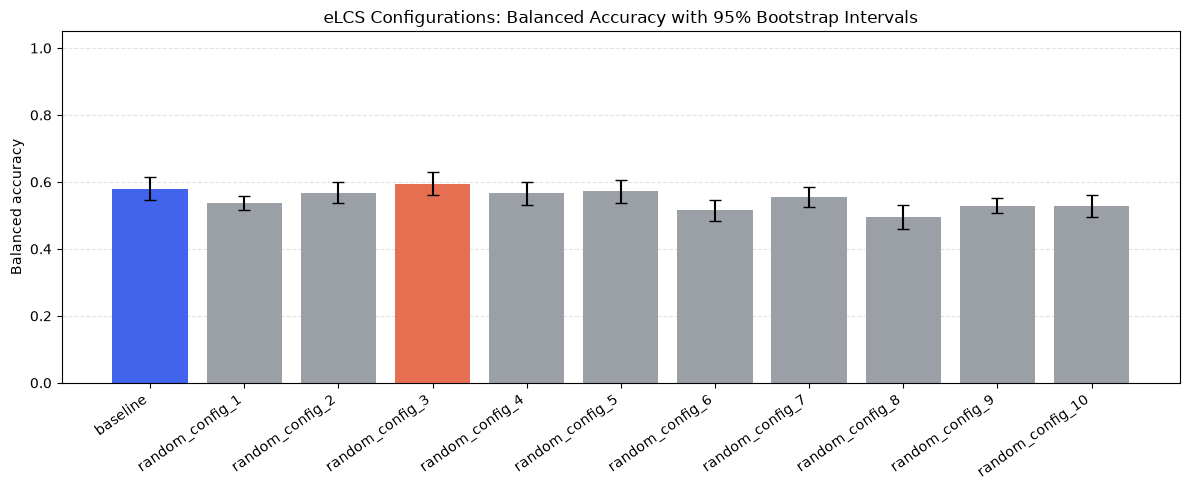

In [45]:
# Pairwise statistical comparison (paired t-test) of baseline and randomized eLCS configurations.
# Balanced accuracy is the comparison metric.
from itertools import combinations
from scipy.stats import ttest_rel
from sklearn.metrics import balanced_accuracy_score

alpha = 0.05
bootstrap_count = 1000
random_generator = np.random.default_rng(42)
# Configuration comparisons are performed on validation data
y_test_values = np.asarray(y_val)
configuration_predictions = elcs_hypertune_results.attrs.get("predictions", {})
configuration_labels = list(elcs_param_grid)

if set(configuration_labels) != set(configuration_predictions):
    raise ValueError(
        "Per-row predictions are missing or do not match the configured models. "
        "Rerun the experiment cell after updating hypertune_elcs."
    )

class_indices = {
    class_label: np.flatnonzero(y_test_values == class_label)
    for class_label in np.unique(y_test_values)
}
if len(class_indices) != 2:
    raise ValueError("Stratified bootstrap comparison requires both test classes.")

bootstrap_balanced_accuracy = {
    label: np.empty(bootstrap_count) for label in configuration_labels
}

for bootstrap_index in range(bootstrap_count):
    sample_indices = np.concatenate(
        [
            random_generator.choice(indices, size=len(indices), replace=True)
            for indices in class_indices.values()
        ]
    )
    sampled_actual = y_test_values[sample_indices]

    for label in configuration_labels:
        bootstrap_balanced_accuracy[label][bootstrap_index] = balanced_accuracy_score(
            sampled_actual,
            configuration_predictions[label][sample_indices],
        )

pairwise_rows = []
raw_p_values = []
for model_a, model_b in combinations(configuration_labels, 2):
    test_result = ttest_rel(
        bootstrap_balanced_accuracy[model_a],
        bootstrap_balanced_accuracy[model_b],
    )
    mean_difference = float(
        np.mean(
            bootstrap_balanced_accuracy[model_b] - bootstrap_balanced_accuracy[model_a]
        )
    )
    raw_p_values.append(test_result.pvalue)
    pairwise_rows.append(
        {
            "Model A": model_a,
            "Model B": model_b,
            "Mean balanced-accuracy difference (B - A)": mean_difference,
            "t-test p-value": test_result.pvalue,
        }
    )

# Holm correction accounts for testing every pair of configurations.
p_values_for_adjustment = np.nan_to_num(raw_p_values, nan=1.0)
order = np.argsort(p_values_for_adjustment)
adjusted_p_values = np.ones(len(raw_p_values))
running_adjusted_p = 0.0
for rank, comparison_index in enumerate(order):
    adjusted_p = min(
        1.0,
        (len(raw_p_values) - rank) * p_values_for_adjustment[comparison_index],
    )
    running_adjusted_p = max(running_adjusted_p, adjusted_p)
    adjusted_p_values[comparison_index] = running_adjusted_p

pairwise_wins = {label: 0 for label in configuration_labels}
for row, adjusted_p_value in zip(pairwise_rows, adjusted_p_values):
    row["Holm-adjusted p-value"] = adjusted_p_value
    row["Significant difference"] = adjusted_p_value < alpha
    if adjusted_p_value < alpha:
        if row["Mean balanced-accuracy difference (B - A)"] > 0:
            pairwise_wins[row["Model B"]] += 1
        elif row["Mean balanced-accuracy difference (B - A)"] < 0:
            pairwise_wins[row["Model A"]] += 1

pairwise_ttest_results = pd.DataFrame(pairwise_rows)
display(
    pairwise_ttest_results.style.format(
        {
            "Mean balanced-accuracy difference (B - A)": "{:+.4f}",
            "t-test p-value": "{:.4g}",
            "Holm-adjusted p-value": "{:.4g}",
        }
    ).hide(axis="index")
)

random_configuration_labels = [
    label for label in configuration_labels if label != "baseline"
]
if not random_configuration_labels:
    raise ValueError("No randomized eLCS configurations are available to select.")

observed_balanced_accuracy = {
    label: balanced_accuracy_score(y_test_values, configuration_predictions[label])
    for label in configuration_labels
}

# The baseline remains in the pairwise comparisons but is never a winner candidate.
unique_random_winners = [
    label
    for label in random_configuration_labels
    if pairwise_wins[label] == len(configuration_labels) - 1
]
if len(unique_random_winners) == 1:
    best_config_label = unique_random_winners[0]
    print(
        "A randomized configuration significantly outperformed every other configuration."
    )
else:
    maximum_pairwise_wins = max(
        pairwise_wins[label] for label in random_configuration_labels
    )
    tied_random_configurations = [
        label
        for label in random_configuration_labels
        if pairwise_wins[label] == maximum_pairwise_wins
    ]
    best_config_label = max(
        tied_random_configurations,
        key=lambda label: observed_balanced_accuracy[label],
    )
    print(
        "No randomized configuration significantly outperformed every other configuration. "
        "Reporting the randomized configuration with the most significant pairwise wins; "
        "ties are broken by observed balanced accuracy."
    )

# Reuse the metrics already calculated and stored by the experiment cell.
results_by_label = elcs_hypertune_results.set_index("label")
comparison_keys = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "balanced_accuracy",
    "mean_cost",
    "roc_auc",
    "prc_auc",
]
baseline_row = results_by_label.loc["baseline"]
best_row = results_by_label.loc[best_config_label]
baseline = {key: baseline_row[key] for key in comparison_keys}
best_accuracy = {key: best_row[key] for key in comparison_keys}
best_accuracy["label"] = f"Best-Random configuration ({best_config_label})"
best_params = elcs_param_grid[best_config_label]
stored_metrics_df = pd.DataFrame(
    [
        {"Name": "baseline", **baseline},
        {"Name": "Best-Random configuration", **best_accuracy},
    ]
)

confusion_matrices = elcs_hypertune_results.attrs.get("confusion_matrices", {})
baseline_cm = confusion_matrices.get("baseline")
best_cm = confusion_matrices.get(best_config_label)

print("\n=== BASELINE eLCS (COMPARATOR) ===")
print(f"Balanced accuracy: {baseline_row['balanced_accuracy']:.4f}")
print("Parameters: default eLCS parameters")

print(f"\n=== BEST-RANDOM eLCS CONFIGURATION: {best_config_label} ===")
print(f"Balanced accuracy: {best_row['balanced_accuracy']:.4f}")
print(
    f"Significant pairwise wins: {pairwise_wins[best_config_label]} of {len(configuration_labels) - 1}"
)
print("Parameters:")
for parameter_name, parameter_value in best_params.items():
    print(f"  {parameter_name}: {parameter_value}")

print(
    "Pairwise tests use 1,000 shared stratified bootstrap resamples of the "
    "validation set. The validation set was used to compare configurations; "
    "the final test set remained untouched until final evaluation."
)

# Plot observed balanced accuracy and 95% stratified-bootstrap intervals.
scores = [
    observed_balanced_accuracy[configuration_label]
    for configuration_label in configuration_labels
]
bootstrap_intervals = {
    configuration_label: np.percentile(
        bootstrap_balanced_accuracy[configuration_label],
        [2.5, 97.5],
    )
    for configuration_label in configuration_labels
}
lower_errors = [
    score - bootstrap_intervals[configuration_label][0]
    for configuration_label, score in zip(configuration_labels, scores)
]
upper_errors = [
    bootstrap_intervals[configuration_label][1] - score
    for configuration_label, score in zip(configuration_labels, scores)
]
bar_colors = [
    (
        "#4263eb"
        if configuration_label == "baseline"
        else "#e76f51" if configuration_label == best_config_label else "#9aa0a6"
    )
    for configuration_label in configuration_labels
]

figure, axis = plt.subplots(figsize=(12, 5))
axis.bar(
    range(len(configuration_labels)),
    scores,
    yerr=np.array([lower_errors, upper_errors]),
    capsize=4,
    color=bar_colors,
)
axis.set_xticks(
    range(len(configuration_labels)),
    labels=configuration_labels,
    rotation=35,
    ha="right",
)
axis.set_ylabel("Balanced accuracy")
axis.set_ylim(0, 1.05)
axis.set_title("eLCS Configurations: Balanced Accuracy with 95% Bootstrap Intervals")
axis.grid(axis="y", linestyle="--", alpha=0.35)
axis.set_axisbelow(True)
figure.tight_layout()
plt.show()

In [46]:
# Final evaluation on the untouched test set.
# Both eLCS models are retrained using the full training data.

baseline_test_metrics, baseline_test_model, _, _, baseline_test_cm, baseline_test_pred = (
    run_elcs_experiment(
        {},
        X_train_raw,
        y_train,
        X_test_raw,
        y_test,
        label="Baseline eLCS - Final Test"
    )
)

best_test_metrics, best_test_model, _, _, best_test_cm, best_test_pred = (
    run_elcs_experiment(
        best_params,
        X_train_raw,
        y_train,
        X_test_raw,
        y_test,
        label=f"Best-Random eLCS ({best_config_label}) - Final Test"
    )
)

print("\n=== FINAL TEST RESULTS ===")
print(
    f"Baseline balanced accuracy: "
    f"{baseline_test_metrics['balanced_accuracy']:.4f}"
)
print(
    f"Best-Random balanced accuracy: "
    f"{best_test_metrics['balanced_accuracy']:.4f}"
)

Executing configuration 'Baseline eLCS - Final Test' with parameters: {}
Executing configuration 'Best-Random eLCS (random_config_3) - Final Test' with parameters: {'learning_iterations': 7600, 'N': 1500, 'p_spec': 0.71, 'nu': 7.8, 'chi': 0.49, 'mu': 0.069, 'theta_sel': 0.29, 'acc_sub': 0.92, 'selection_method': 'roulette', 'do_correct_set_subsumption': False, 'track_accuracy_while_fit': False, 'random_state': 45}

=== FINAL TEST RESULTS ===
Baseline balanced accuracy: 0.5842
Best-Random balanced accuracy: 0.5630


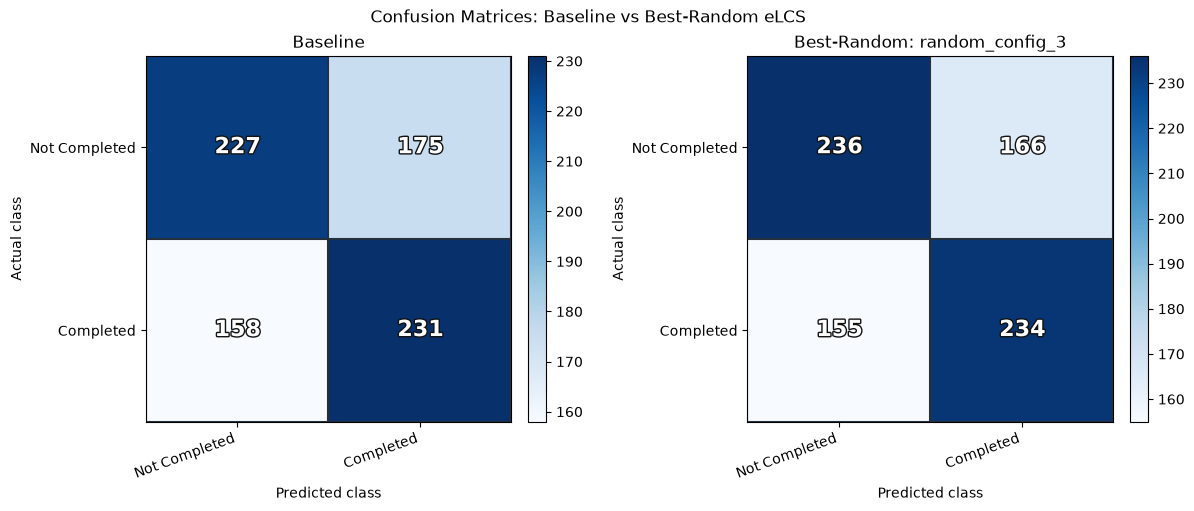

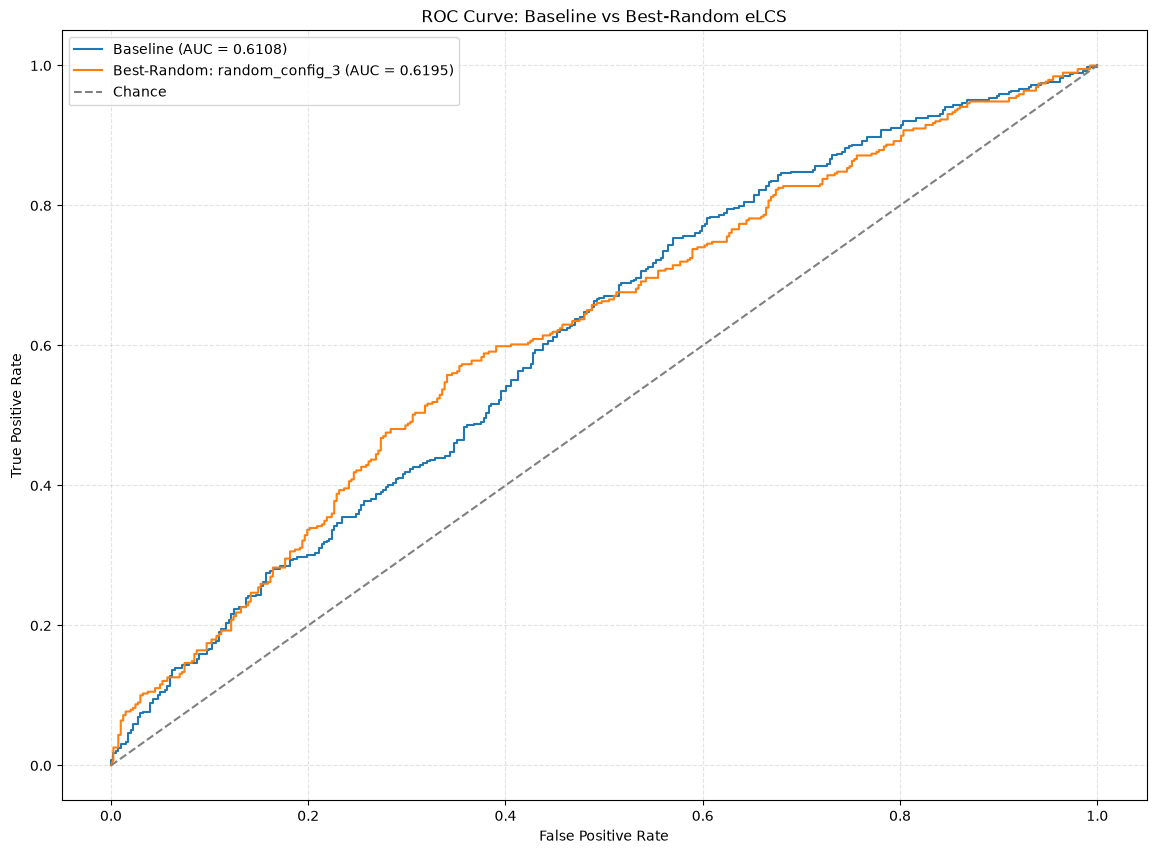

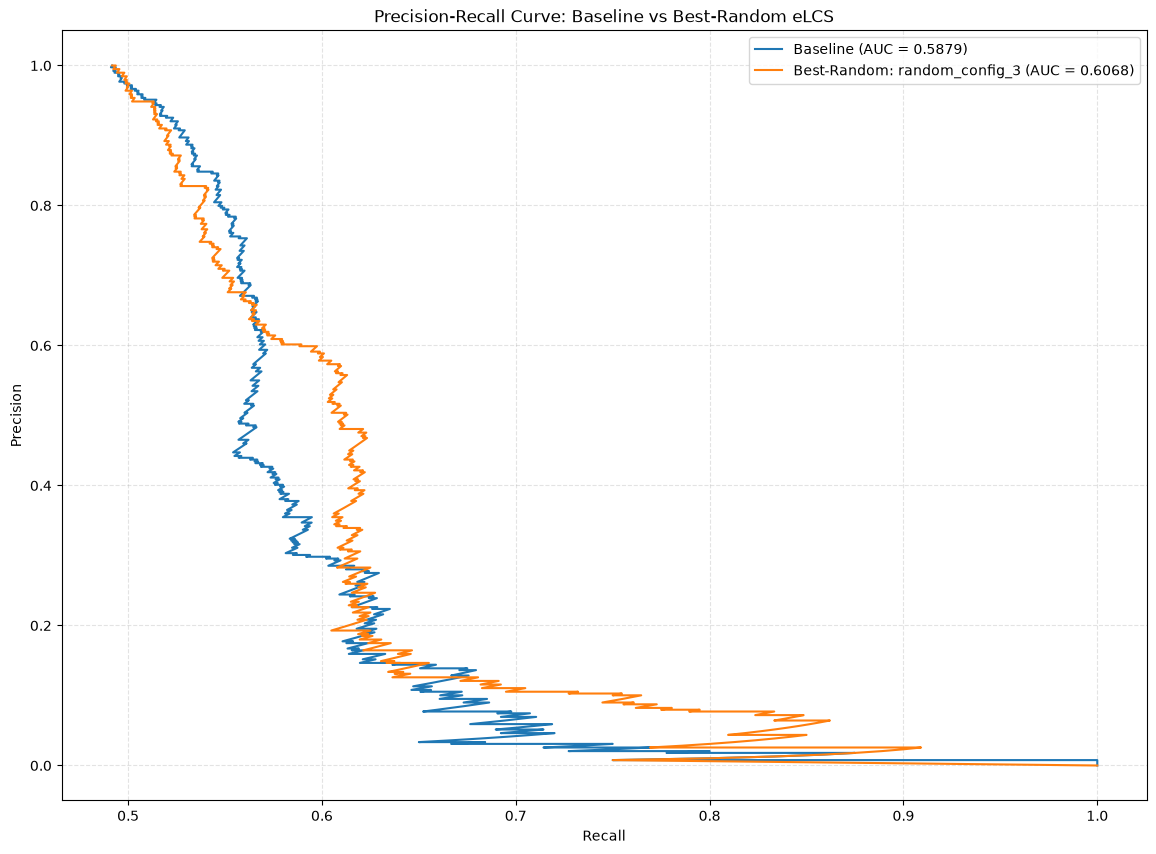

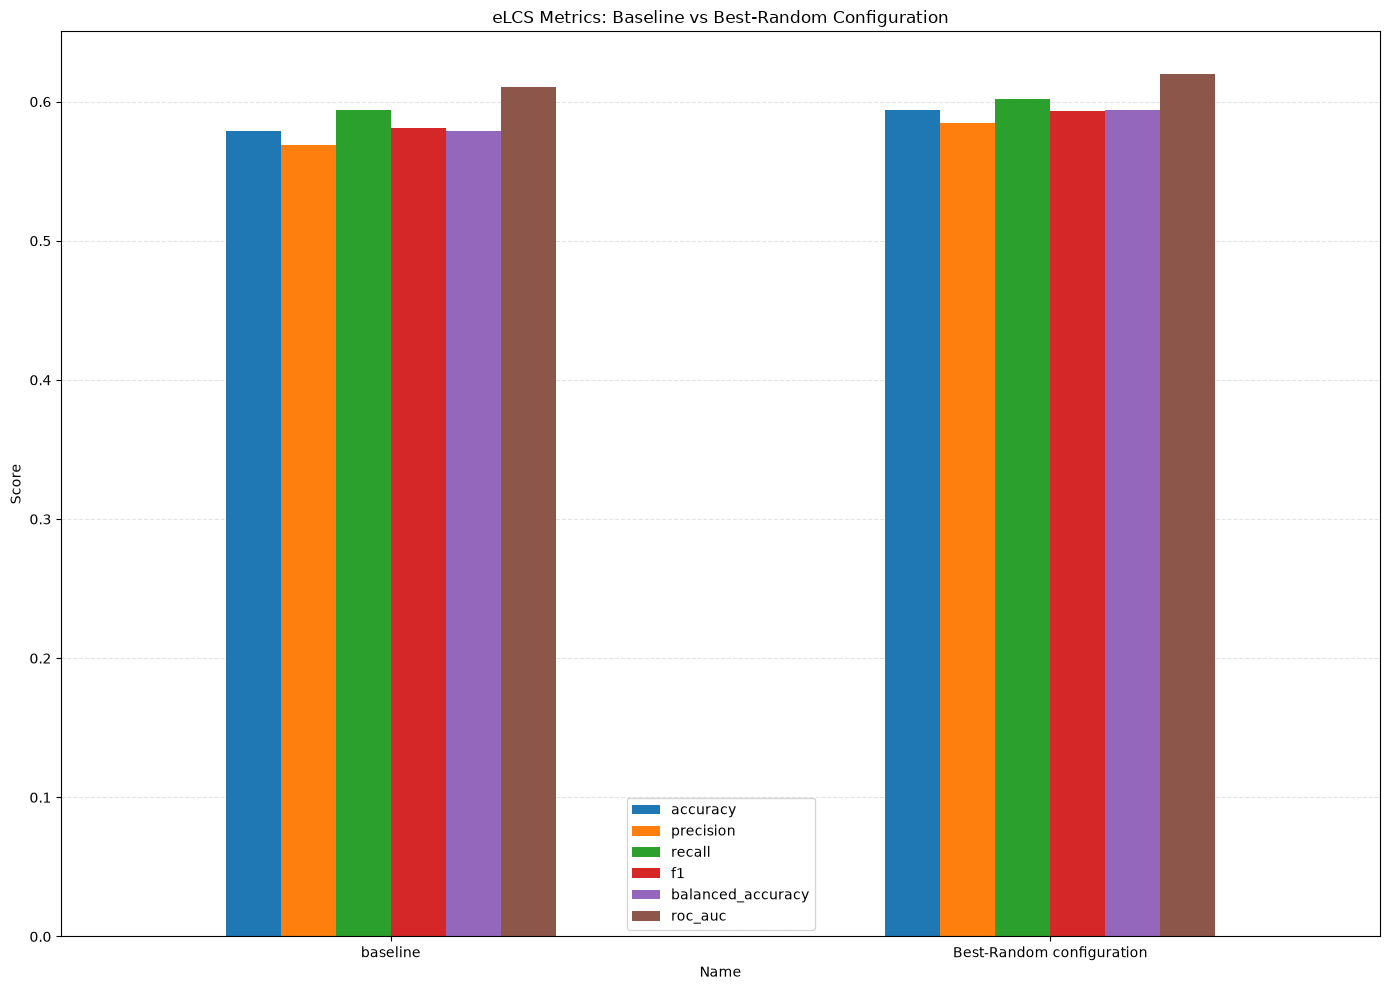

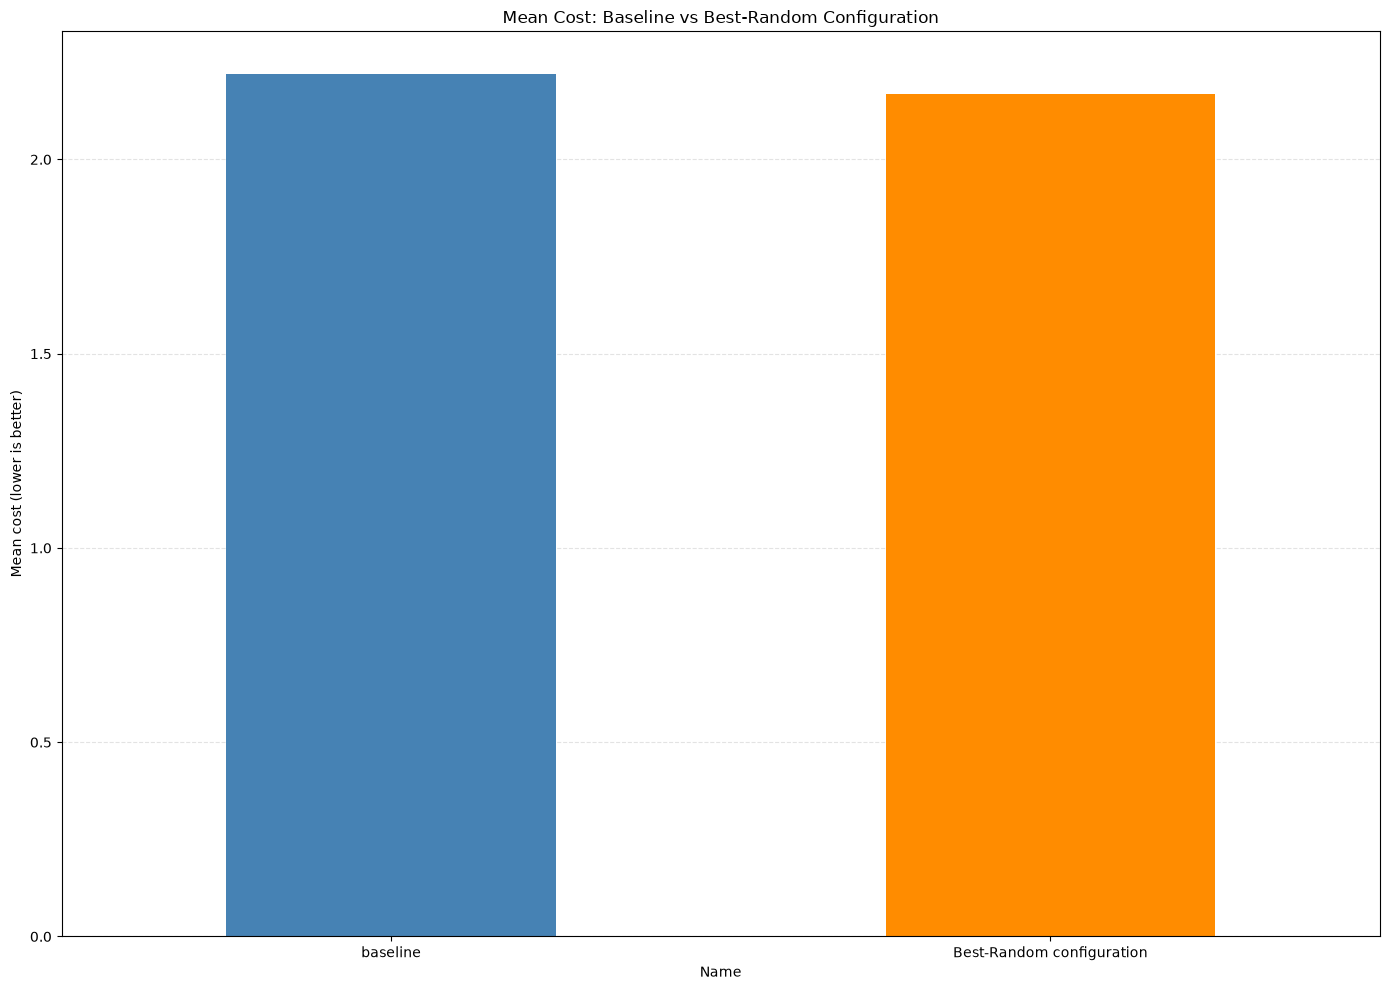

In [47]:
# Plot comparison graphs for Baseline vs the Best-Random eLCS configuration.
import matplotlib.patheffects as path_effects

baseline_roc = elcs_hypertune_results.attrs["roc_curves"]["baseline"]
best_roc = elcs_hypertune_results.attrs["roc_curves"][best_config_label]
baseline_prc = elcs_hypertune_results.attrs["prc_curves"]["baseline"]
best_prc = elcs_hypertune_results.attrs["prc_curves"][best_config_label]

# Plot confusion matrices side by side. Rows are actual classes; columns are predictions.
confusion_matrices_to_plot = [
    ("Baseline", baseline_cm),
    (f"Best-Random: {best_config_label}", best_cm),
]
class_labels = ["Not Completed", "Completed"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for axis, (model_label, matrix) in zip(axes, confusion_matrices_to_plot):
    image = axis.imshow(matrix, cmap="Blues")
    axis.set_title(model_label)
    axis.set_xlabel("Predicted class")
    axis.set_ylabel("Actual class")
    axis.set_xticks(
        range(len(class_labels)), labels=class_labels, rotation=20, ha="right"
    )
    axis.set_yticks(range(len(class_labels)), labels=class_labels)
    axis.set_xticks([index - 0.5 for index in range(matrix.shape[1] + 1)], minor=True)
    axis.set_yticks([index - 0.5 for index in range(matrix.shape[0] + 1)], minor=True)
    axis.grid(which="minor", color="#24313D", linestyle="-", linewidth=1.5)
    axis.tick_params(which="minor", bottom=False, left=False)

    threshold = matrix.max() / 2
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            value = matrix[row_index, column_index]
            text_color = "white" if value > threshold else "#111111"
            outline_color = "#111111" if text_color == "white" else "white"
            axis.text(
                column_index,
                row_index,
                str(value),
                ha="center",
                va="center",
                fontsize=16,
                fontweight="bold",
                color=text_color,
                path_effects=[
                    path_effects.withStroke(linewidth=2, foreground=outline_color)
                ],
            )

    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

fig.suptitle("Confusion Matrices: Baseline vs Best-Random eLCS")
plt.show()

plt.figure(figsize=(14, 10))
plt.plot(
    baseline_roc[0],
    baseline_roc[1],
    label=f"Baseline (AUC = {baseline['roc_auc']:.4f})",
)
plt.plot(
    best_roc[0],
    best_roc[1],
    label=f"Best-Random: {best_config_label} (AUC = {best_accuracy['roc_auc']:.4f})",
)
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Baseline vs Best-Random eLCS")
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend()
plt.show()

plt.figure(figsize=(14, 10))
plt.plot(
    baseline_prc[1],
    baseline_prc[0],
    label=f"Baseline (AUC = {baseline['prc_auc']:.4f})",
)
plt.plot(
    best_prc[1],
    best_prc[0],
    label=f"Best-Random: {best_config_label} (AUC = {best_accuracy['prc_auc']:.4f})",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: Baseline vs Best-Random eLCS")
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend()
plt.show()

elcs_metrics_to_plot = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "balanced_accuracy",
    "roc_auc",
]
metrics_axis = stored_metrics_df.set_index("Name")[elcs_metrics_to_plot].plot(
    kind="bar",
    figsize=(14, 10),
)
metrics_axis.set_axisbelow(True)
metrics_axis.grid(axis="y", linestyle="--", alpha=0.35)
metrics_axis.set_ylabel("Score")
metrics_axis.set_title("eLCS Metrics: Baseline vs Best-Random Configuration")
metrics_axis.tick_params(axis="x", rotation=0)
metrics_axis.figure.tight_layout()
plt.show()

cost_axis = stored_metrics_df.set_index("Name")["mean_cost"].plot(
    kind="bar",
    figsize=(14, 10),
    color=["steelblue", "darkorange"],
)
cost_axis.set_axisbelow(True)
cost_axis.grid(axis="y", linestyle="--", alpha=0.35)
cost_axis.set_ylabel("Mean cost (lower is better)")
cost_axis.set_title("Mean Cost: Baseline vs Best-Random Configuration")
cost_axis.tick_params(axis="x", rotation=0)
cost_axis.figure.tight_layout()
plt.show()

In [48]:
# Extract top 3 rules from the baseline and Best-Random configurations.
# Rule strength is a heuristic: fitness multiplied by classifier numerosity.

# Train the baseline eLCS configuration and export its final rule population.
baseline_rule_model = eLCS(**elcs_param_grid["baseline"])
baseline_rule_model.fit(
    X_train_raw.to_numpy(),
    y_train.to_numpy(),
)

baseline_rule_file = "../data/export/elcs_rules_baseline.csv"
baseline_rule_model.export_final_rule_population(
    headerNames=X_train_raw.columns.to_numpy(),
    className="Completed",
    filename=baseline_rule_file,
    DCAL=False,
)

baseline_rule_population = pd.read_csv(baseline_rule_file)
baseline_rule_population["Rule Strength"] = (
    baseline_rule_population["Fitness"] * baseline_rule_population["Numerosity"]
)
baseline_rule_population.insert(0, "Configuration", "baseline")

important_elcs_baseline_rules = (
    baseline_rule_population.sort_values(
        ["Rule Strength", "Accuracy", "Match Count"],
        ascending=False,
    )
    .head(3)
    .copy()
    .reset_index(drop=True)
)
important_elcs_baseline_rules.insert(
    0, "Rank", range(1, len(important_elcs_baseline_rules) + 1)
)

print("Top 3 rules from the baseline eLCS configuration:")
display(important_elcs_baseline_rules.style.hide(axis="index"))
print(f"Exported baseline rule population to {baseline_rule_file}.")

# Train the Best-Random configuration and export its final rule population.
rule_model = eLCS(**elcs_param_grid[best_config_label])
rule_model.fit(
    X_train_raw.to_numpy(),
    y_train.to_numpy(),
)

best_rule_file = "../data/export/elcs_rules_best_random.csv"
rule_model.export_final_rule_population(
    headerNames=X_train_raw.columns.to_numpy(),
    className="Completed",
    filename=best_rule_file,
    DCAL=False,
)

rule_population = pd.read_csv(best_rule_file)
rule_population["Rule Strength"] = (
    rule_population["Fitness"] * rule_population["Numerosity"]
)
rule_population.insert(0, "Configuration", best_config_label)

important_elcs_rules = (
    rule_population.sort_values(
        ["Rule Strength", "Accuracy", "Match Count"],
        ascending=False,
    )
    .head(3)
    .copy()
    .reset_index(drop=True)
)
important_elcs_rules.insert(0, "Rank", range(1, len(important_elcs_rules) + 1))

print(f"\nTop 3 rules from the Best-Random configuration ({best_config_label}):")
display(important_elcs_rules.style.hide(axis="index"))
print(f"Exported Best-Random rule population to {best_rule_file}.")

Top 3 rules from the baseline eLCS configuration:


Rank,Configuration,Age,Employment_Status,City,Internet_Connection_Quality,Video_Completion_Rate,Quiz_Score_Avg,Progress_Percentage,Payment_Mode,Fee_Paid,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Completed,Fitness,Accuracy,Numerosity,Avg Match Set Size,TimeStamp GA,Iteration Initialized,Specificity,Deletion Probability,Correct Count,Match Count,Rule Strength
1,baseline,#,#,#,#,#,#,0.0,#,#,#,#,#,"-4.31234186262562,1.1907948235421515",#,"-2.5019373145297887,-0.7925653525438665",#,"-2.4288019336091806,2.803979653195993",#,"-1.7435524572525796,1.0031517203424625",0.000000,1.000000,1.000000,2,102.200000,9916,9890,0.263158,0.002050,5,5,2.000000
2,baseline,4.0,2.0,"-1.3599999999999999,5.359999999999999",1.0,4.0,0.0,4.0,0.0,1.0,#,"-2.85280582666563,2.9050596486463967",#,"-0.8757332362573279,1.5629587812547805","-0.4753264968646389,2.11723567294272",#,#,#,#,"-1.5486385898671275,2.631128636907937",1.000000,1.000000,1.000000,2,49.000000,8003,97,0.684211,0.000983,3,3,2.000000
3,baseline,3.0,2.0,"4.38,13.620000000000001",1.0,4.0,#,3.0,#,#,"-3.3547826428657834,3.378230023741358",#,#,"-3.8872897455676005,1.137893805669471","1.7843356925423406,3.7483979423964007",#,"-1.800312209841928,1.509484616806971",#,#,"-0.3596842015348106,2.3273090156777303",0.000000,1.000000,1.000000,2,33.000000,8019,113,0.578947,0.000662,3,3,2.000000


Exported baseline rule population to ../data/export/elcs_rules_baseline.csv.

Top 3 rules from the Best-Random configuration (random_config_3):


Rank,Configuration,Age,Employment_Status,City,Internet_Connection_Quality,Video_Completion_Rate,Quiz_Score_Avg,Progress_Percentage,Payment_Mode,Fee_Paid,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Completed,Fitness,Accuracy,Numerosity,Avg Match Set Size,TimeStamp GA,Iteration Initialized,Specificity,Deletion Probability,Correct Count,Match Count,Rule Strength
1,random_config_3,#,#,"0.5700000000000003,7.43",#,#,#,0.0,2.0,0.0,"-4.210953925879235,2.6210736328838946",#,"-2.6453699017249366,0.4297296177111996",#,#,#,#,#,#,"-0.6385037103544913,3.7801073579505764",0.000000,1.000000,1.000000,2,49.504000,7554,7223,0.368421,0.001581,7,7,2.000000
2,random_config_3,#,0.0,#,2.0,#,#,1.0,2.0,0.0,#,#,#,#,"-2.993946942365395,2.583989847220135",#,#,#,"-5.3224790348431625,2.5607321376892536",#,0.000000,1.000000,1.000000,2,39.800000,7479,6690,0.368421,0.001271,6,6,2.000000
3,random_config_3,#,#,#,#,1.0,#,1.0,4.0,#,"-2.0493203812992187,0.5250668147564528",#,#,#,#,"-0.5262503609461173,1.1909005291088546",#,"-0.845491573680846,1.823354100221664","-3.090173269234694,0.6672251474098574",#,0.000000,1.000000,1.000000,2,18.400000,7078,4727,0.368421,0.000588,5,5,2.000000


Exported Best-Random rule population to ../data/export/elcs_rules_best_random.csv.


#### Using conventional models 


Logistic Regression
-------------------
          accuracy: 0.5940
         precision: 0.5864
            recall: 0.5816
                f1: 0.5840
 balanced_accuracy: 0.5938
         mean_cost: 2.2510
           roc_auc: 0.6553
           prc_auc: 0.6223
Confusion Matrix:
[[309 201]
 [205 285]]

Decision Tree
-------------
          accuracy: 0.5430
         precision: 0.5320
            recall: 0.5592
                f1: 0.5453
 balanced_accuracy: 0.5433
         mean_cost: 2.4010
           roc_auc: 0.5433
           prc_auc: 0.6536
Confusion Matrix:
[[269 241]
 [216 274]]

Random Forest (2000 trees)
--------------------------
          accuracy: 0.5840
         precision: 0.5737
            recall: 0.5878
                f1: 0.5806
 balanced_accuracy: 0.5841
         mean_cost: 2.2340
           roc_auc: 0.6342
           prc_auc: 0.6116
Confusion Matrix:
[[296 214]
 [202 288]]

Conventional classifiers ranked by balanced accuracy:


Rank,label,accuracy,precision,recall,f1,balanced_accuracy,mean_cost,roc_auc,prc_auc
1,Logistic Regression,0.594000,0.586420,0.581633,0.584016,0.593758,2.251000,0.655326,0.622338
2,Random Forest (2000 trees),0.584000,0.573705,0.587755,0.580645,0.584074,2.234000,0.634174,0.611606
3,Decision Tree,0.543000,0.532039,0.559184,0.545274,0.543317,2.401000,0.543317,0.653611


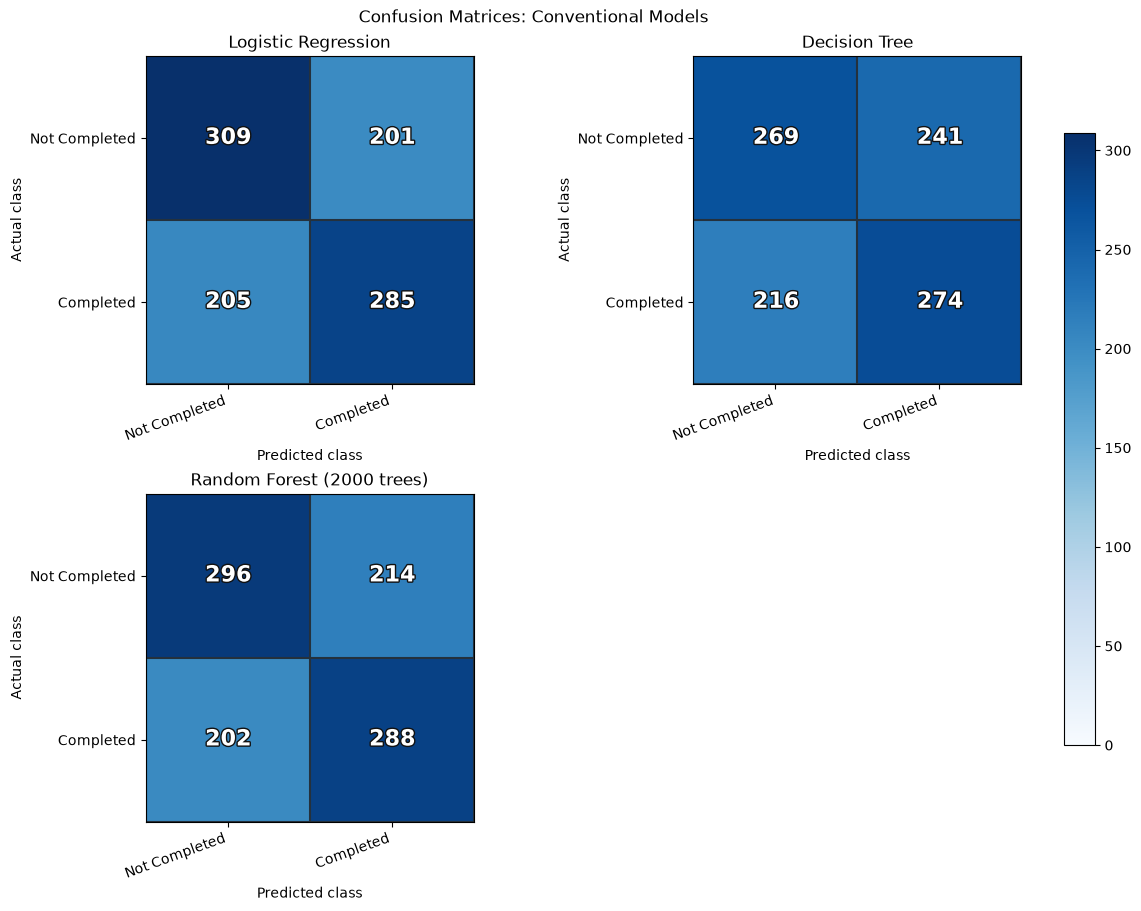

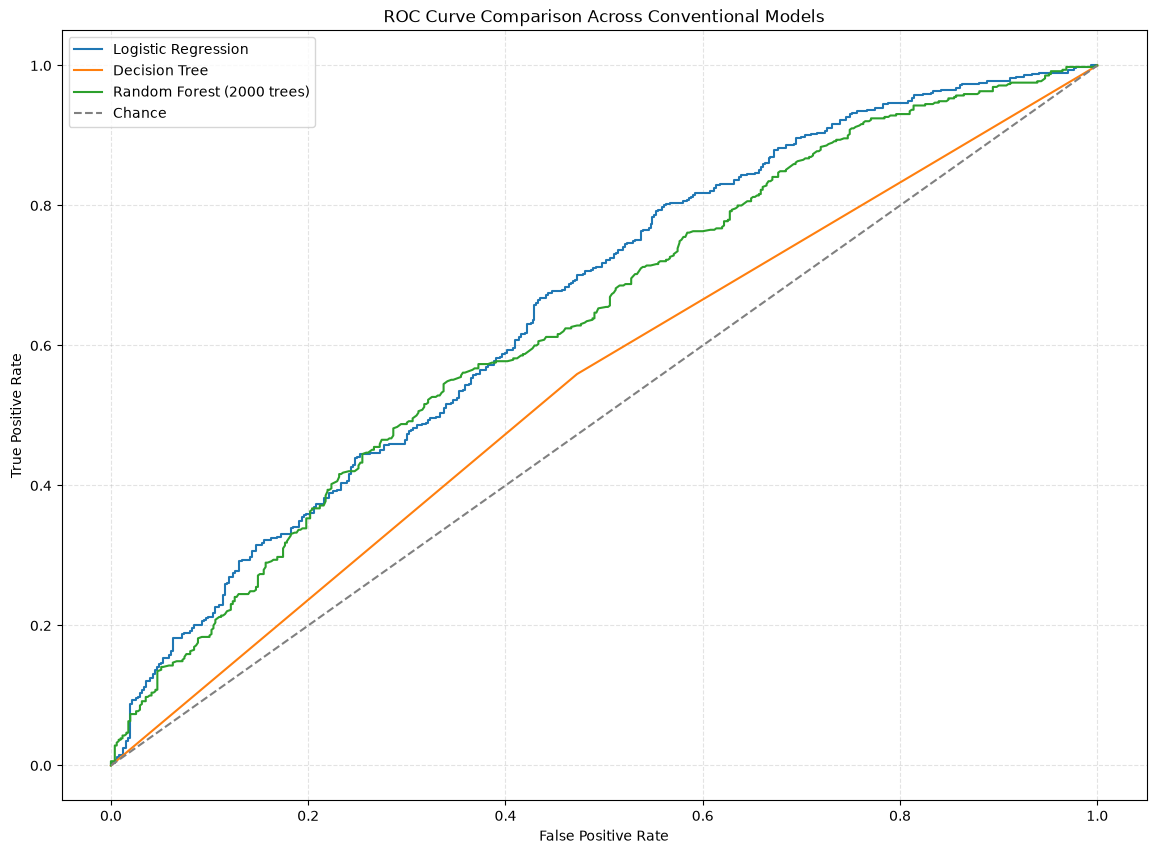

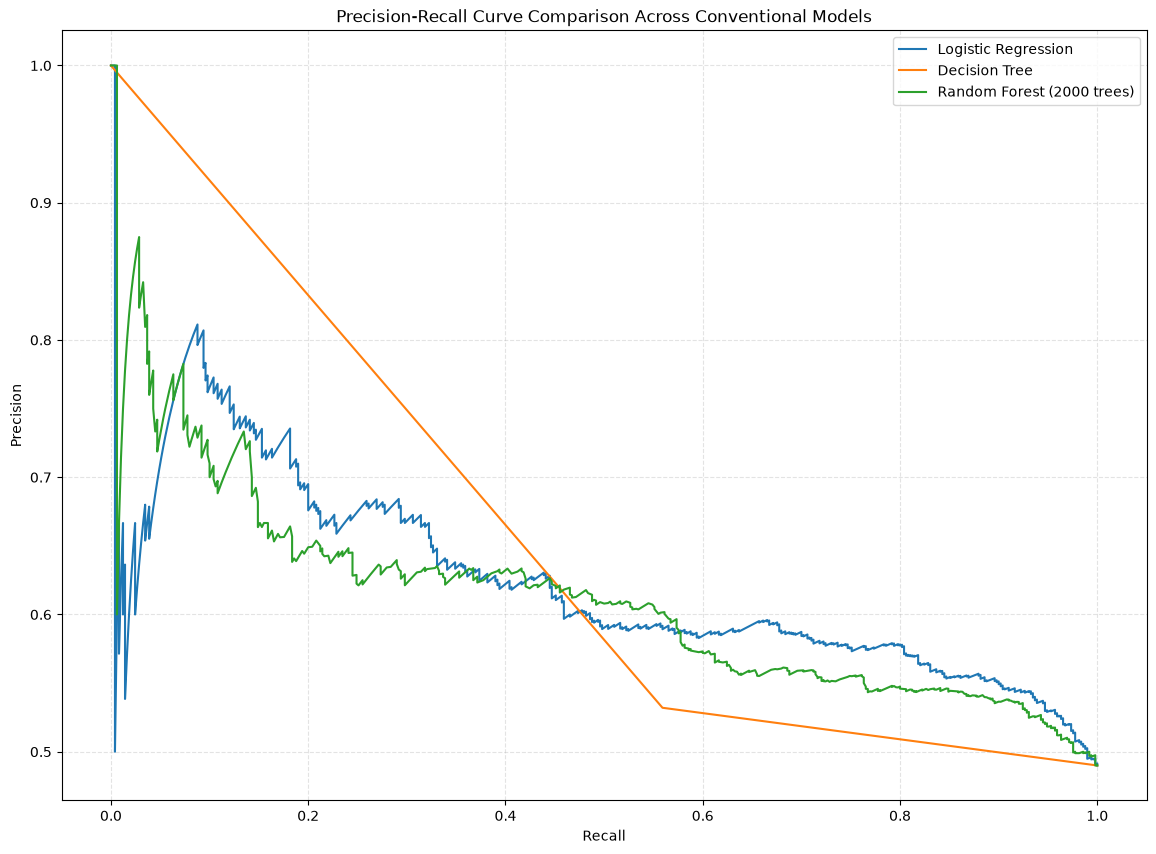

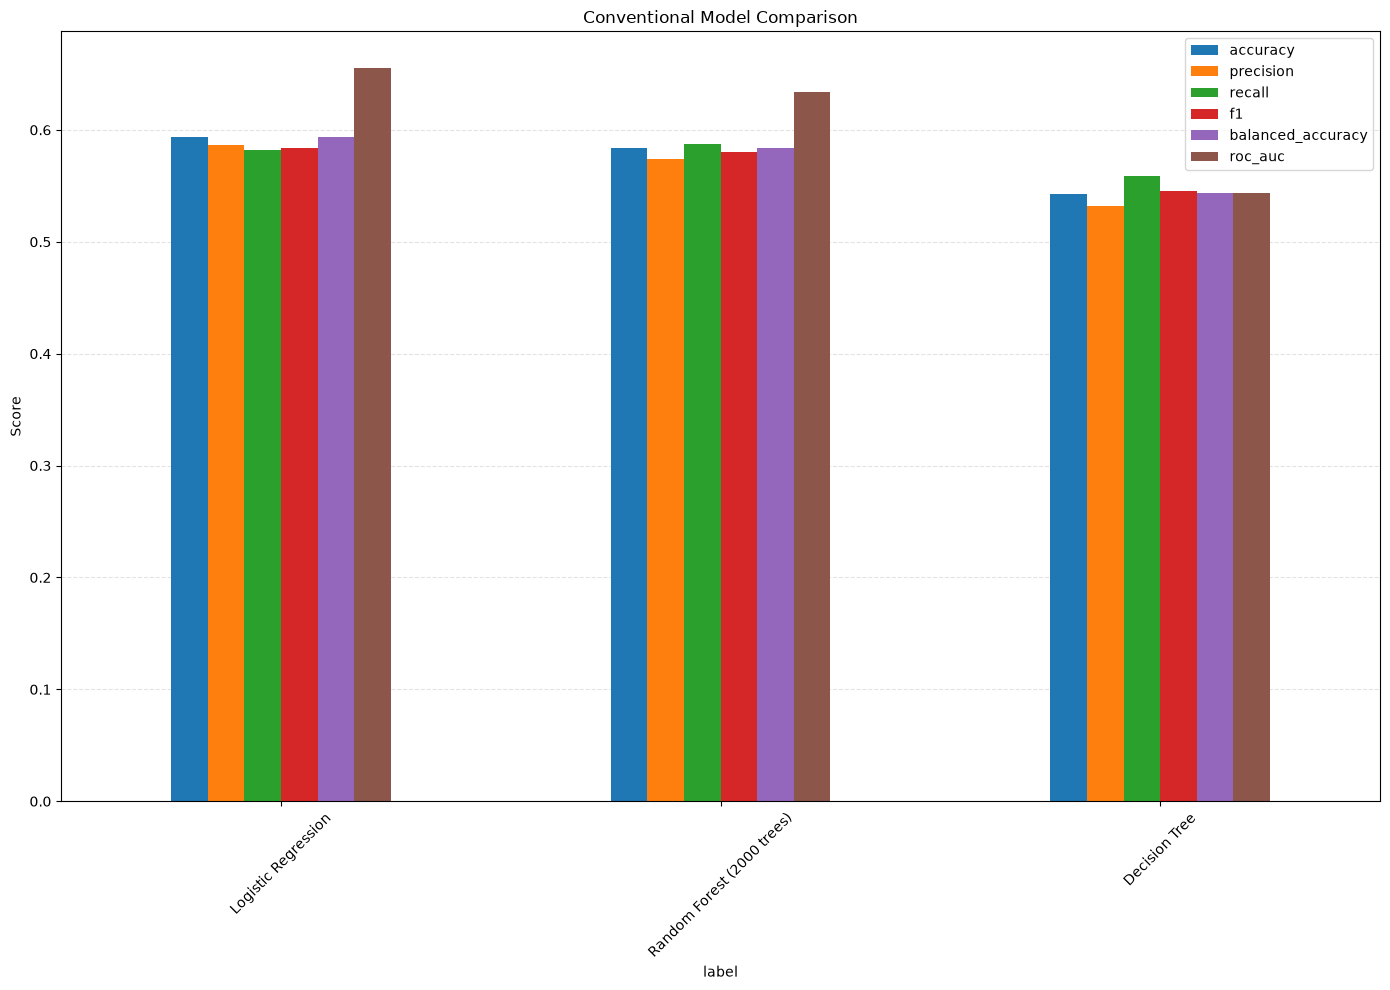

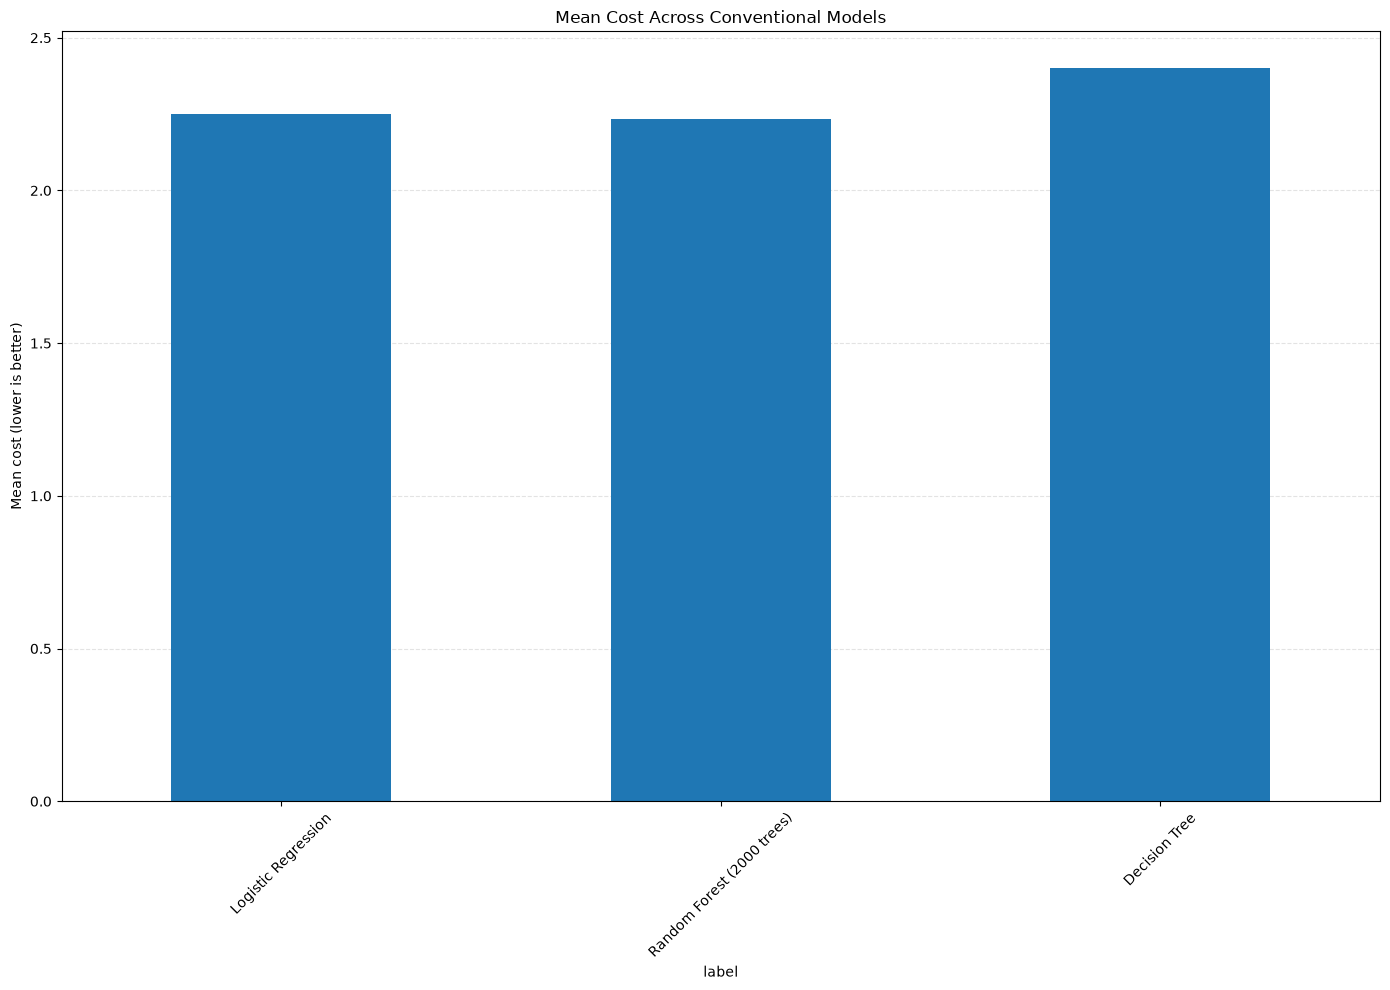

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.patheffects as path_effects

conventional_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest (2000 trees)": RandomForestClassifier(
        n_estimators=2000,
        random_state=42,
        n_jobs=-1,
    ),
}

conventional_results = []
conventional_roc_curves = {}
conventional_prc_curves = {}
conventional_confusion_matrices = {}
false_negative_cost = 10.0
false_positive_cost = 1.0

for model_label, model in conventional_models.items():
    model.fit(X_train_raw, y_train)
    y_pred = model.predict(X_test_raw)
    probabilities = model.predict_proba(X_test_raw)
    positive_class_index = list(model.classes_).index(1)
    positive_probabilities = probabilities[:, positive_class_index]

    false_negatives = ((y_test == 1) & (y_pred == 0)).sum()
    false_positives = ((y_test == 0) & (y_pred == 1)).sum()
    mean_cost = (
        false_negative_cost * false_negatives + false_positive_cost * false_positives
    ) / len(y_test)

    fpr, tpr, _ = roc_curve(y_test, positive_probabilities)
    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test, positive_probabilities
    )
    model_confusion_matrix = confusion_matrix(y_test, y_pred, labels=[0, 1])

    metrics = {
        "label": model_label,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "mean_cost": mean_cost,
        "roc_auc": auc(fpr, tpr),
        "prc_auc": auc(recall_curve, precision_curve),
    }
    conventional_results.append(metrics)
    conventional_roc_curves[model_label] = (fpr, tpr)
    conventional_prc_curves[model_label] = (recall_curve, precision_curve)
    conventional_confusion_matrices[model_label] = model_confusion_matrix

    print(f"\n{model_label}")
    print("-" * len(model_label))
    for metric_name, metric_value in metrics.items():
        if metric_name != "label":
            print(f"{metric_name:>18}: {metric_value:.4f}")
    print("Confusion Matrix:")
    print(model_confusion_matrix)

conventional_results_df = (
    pd.DataFrame(conventional_results)
    .sort_values("balanced_accuracy", ascending=False)
    .reset_index(drop=True)
)
conventional_results_df.insert(0, "Rank", range(1, len(conventional_results_df) + 1))

print("\nConventional classifiers ranked by balanced accuracy:")
display(conventional_results_df.style.hide(axis="index"))

# Use a 2x2 layout so class labels and the shared colorbar do not crowd the panels.
class_labels = ["Not Completed", "Completed"]
confusion_matrix_max = max(
    matrix.max() for matrix in conventional_confusion_matrices.values()
)
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
axes = axes.ravel()

for axis, (model_label, matrix) in zip(axes, conventional_confusion_matrices.items()):
    image = axis.imshow(matrix, cmap="Blues", vmin=0, vmax=confusion_matrix_max)
    axis.set_title(model_label)
    axis.set_xlabel("Predicted class")
    axis.set_ylabel("Actual class")
    axis.set_xticks(
        range(len(class_labels)), labels=class_labels, rotation=20, ha="right"
    )
    axis.set_yticks(range(len(class_labels)), labels=class_labels)
    axis.set_xticks([index - 0.5 for index in range(matrix.shape[1] + 1)], minor=True)
    axis.set_yticks([index - 0.5 for index in range(matrix.shape[0] + 1)], minor=True)
    axis.grid(which="minor", color="#24313D", linestyle="-", linewidth=1.5)
    axis.tick_params(which="minor", bottom=False, left=False)

    threshold = matrix.max() / 2
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            value = matrix[row_index, column_index]
            text_color = "white" if value > threshold else "#111111"
            outline_color = "#111111" if text_color == "white" else "white"
            axis.text(
                column_index,
                row_index,
                str(value),
                ha="center",
                va="center",
                fontsize=16,
                fontweight="bold",
                color=text_color,
                path_effects=[
                    path_effects.withStroke(linewidth=2, foreground=outline_color)
                ],
            )

axes[-1].set_visible(False)
fig.colorbar(
    image, ax=axes[: len(conventional_confusion_matrices)], shrink=0.8, pad=0.04
)
fig.suptitle("Confusion Matrices: Conventional Models")
plt.show()

plt.figure(figsize=(14, 10))
for model_label, (fpr, tpr) in conventional_roc_curves.items():
    plt.plot(fpr, tpr, label=model_label)
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison Across Conventional Models")
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend()
plt.show()

plt.figure(figsize=(14, 10))
for model_label, (recall_curve, precision_curve) in conventional_prc_curves.items():
    plt.plot(recall_curve, precision_curve, label=model_label)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison Across Conventional Models")
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend()
plt.show()

conventional_metrics_to_plot = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "balanced_accuracy",
    "roc_auc",
]
metrics_axis = conventional_results_df.set_index("label")[
    conventional_metrics_to_plot
].plot(
    kind="bar",
    figsize=(14, 10),
)
metrics_axis.set_axisbelow(True)
metrics_axis.grid(axis="y", linestyle="--", alpha=0.35)
metrics_axis.set_ylabel("Score")
metrics_axis.set_title("Conventional Model Comparison")
metrics_axis.tick_params(axis="x", rotation=45)
metrics_axis.figure.tight_layout()
plt.show()

cost_axis = conventional_results_df.set_index("label")["mean_cost"].plot(
    kind="bar", figsize=(14, 10)
)
cost_axis.set_axisbelow(True)
cost_axis.grid(axis="y", linestyle="--", alpha=0.35)
cost_axis.set_ylabel("Mean cost (lower is better)")
cost_axis.set_title("Mean Cost Across Conventional Models")
cost_axis.tick_params(axis="x", rotation=45)
cost_axis.figure.tight_layout()
plt.show()

#### Pairwise statistical comparison (paired t-test) between Baseline, Best-Random eLCS configuration, and conventional models

Model A,Model B,Balanced-accuracy difference (B - A),95% paired-bootstrap CI,Centered-bootstrap p-value,Holm-adjusted p-value,Significant at 0.05
Baseline eLCS,Best-Random eLCS (random_config_3),-0.0211,"[-0.0543, +0.0120]",0.1898,1,False
Baseline eLCS,Logistic Regression,+0.0096,"[-0.0170, +0.0339]",0.4645,1,False
Baseline eLCS,Decision Tree,-0.0408,"[-0.0823, -0.0013]",0.04795,0.3836,False
Baseline eLCS,Random Forest (2000 trees),-0.0001,"[-0.0305, +0.0289]",0.993,1,False
Best-Random eLCS (random_config_3),Logistic Regression,+0.0308,"[-0.0012, +0.0648]",0.06394,0.4476,False
Best-Random eLCS (random_config_3),Decision Tree,-0.0197,"[-0.0588, +0.0192]",0.3147,1,False
Best-Random eLCS (random_config_3),Random Forest (2000 trees),+0.0211,"[-0.0090, +0.0550]",0.2318,1,False
Logistic Regression,Decision Tree,-0.0504,"[-0.0898, -0.0080]",0.01998,0.1998,False
Logistic Regression,Random Forest (2000 trees),-0.0097,"[-0.0355, +0.0157]",0.4695,1,False
Decision Tree,Random Forest (2000 trees),+0.0408,"[+0.0046, +0.0791]",0.03497,0.3147,False


Observed balanced accuracy:
  Baseline eLCS: 0.5842
  Best-Random eLCS (random_config_3): 0.5630
  Logistic Regression: 0.5938
  Decision Tree: 0.5433
  Random Forest (2000 trees): 0.5841
Pairwise tests use 1,000 shared stratified bootstrap resamples with centered two-sided p-values and Holm correction. The test set was used for model comparison, so treat results as exploratory.


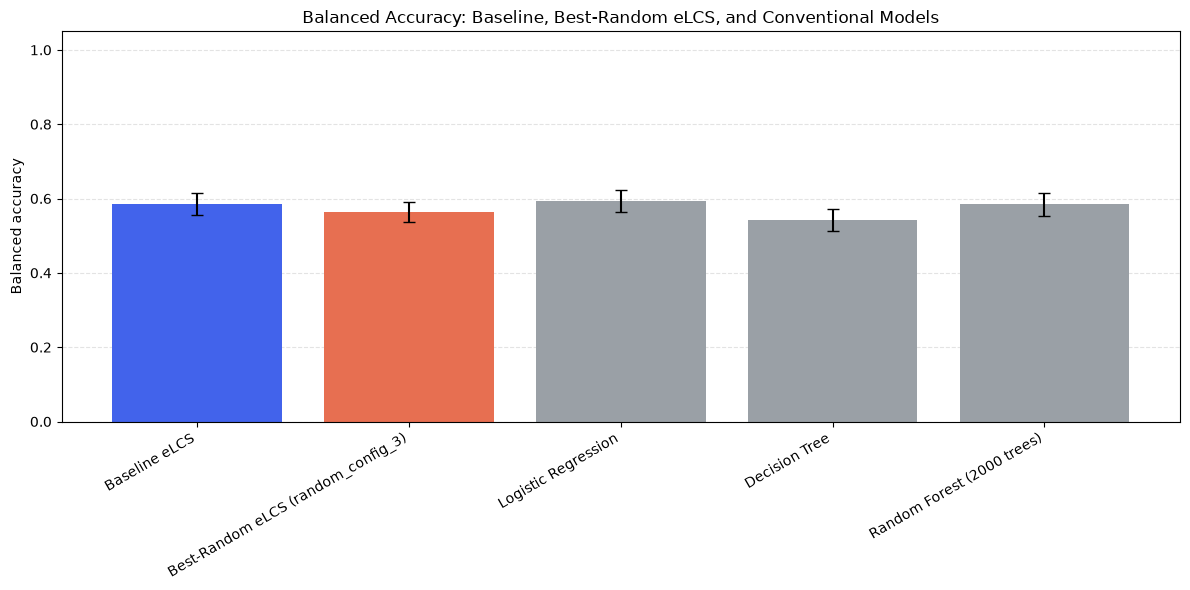

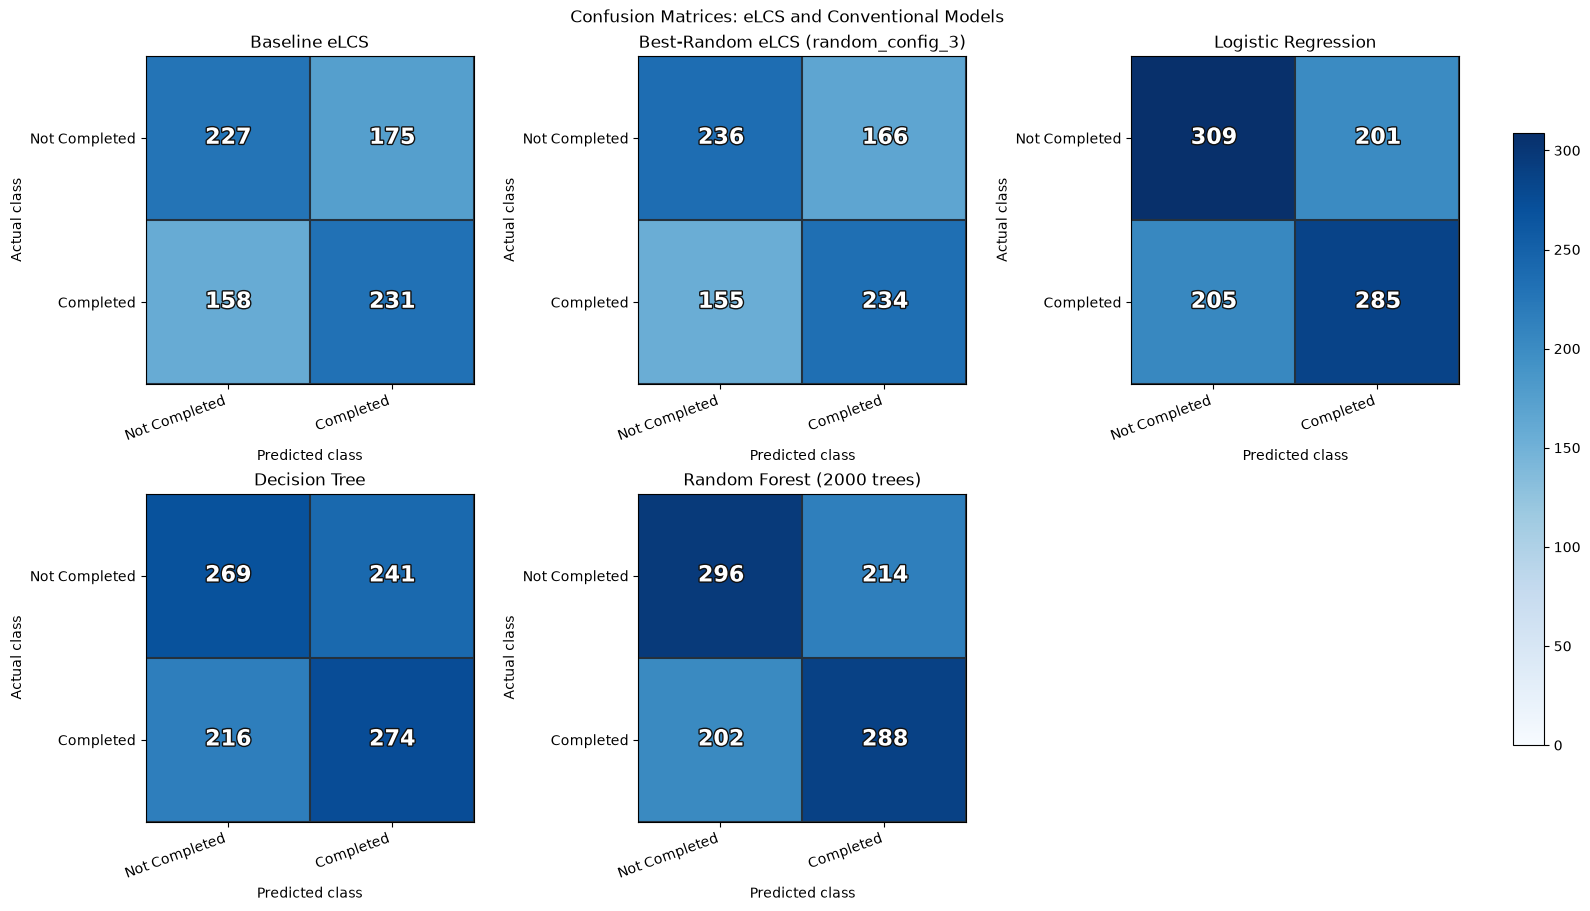

In [50]:
# Compare balanced accuracy across baseline, Best-Random eLCS, and conventional models.
from itertools import combinations
from sklearn.metrics import balanced_accuracy_score

# Use eLCS predictions from the final untouched test set
comparison_predictions = {
    "Baseline eLCS": baseline_test_pred,
    f"Best-Random eLCS ({best_config_label})": best_test_pred,
}
comparison_predictions.update(
    {
        model_label: model.predict(X_test_raw)
        for model_label, model in conventional_models.items()
    }
)

comparison_labels = list(comparison_predictions)
# Configuration comparisons are performed on validation data
y_test_values = np.asarray(y_test)
class_indices = {
    class_label: np.flatnonzero(y_test_values == class_label)
    for class_label in np.unique(y_test_values)
}
if len(class_indices) != 2:
    raise ValueError(
        "Stratified balanced-accuracy comparison requires both test classes."
    )

bootstrap_count = 1000
random_generator = np.random.default_rng(42)
bootstrap_scores = {label: np.empty(bootstrap_count) for label in comparison_labels}

for bootstrap_index in range(bootstrap_count):
    sample_indices = np.concatenate(
        [
            random_generator.choice(indices, size=len(indices), replace=True)
            for indices in class_indices.values()
        ]
    )
    sampled_actual = y_test_values[sample_indices]

    for label in comparison_labels:
        bootstrap_scores[label][bootstrap_index] = balanced_accuracy_score(
            sampled_actual,
            comparison_predictions[label][sample_indices],
        )

comparison_rows = []
raw_p_values = []
for model_a, model_b in combinations(comparison_labels, 2):
    observed_difference = balanced_accuracy_score(
        y_test_values, comparison_predictions[model_b]
    ) - balanced_accuracy_score(y_test_values, comparison_predictions[model_a])
    bootstrap_differences = bootstrap_scores[model_b] - bootstrap_scores[model_a]
    centered_differences = bootstrap_differences - observed_difference
    p_value = (
        1 + np.count_nonzero(np.abs(centered_differences) >= abs(observed_difference))
    ) / (bootstrap_count + 1)
    confidence_interval = np.percentile(bootstrap_differences, [2.5, 97.5])

    raw_p_values.append(p_value)
    comparison_rows.append(
        {
            "Model A": model_a,
            "Model B": model_b,
            "Balanced-accuracy difference (B - A)": observed_difference,
            "95% paired-bootstrap CI": (
                f"[{confidence_interval[0]:+.4f}, {confidence_interval[1]:+.4f}]"
            ),
            "Centered-bootstrap p-value": p_value,
        }
    )

# Holm correction controls family-wise error across all pairwise comparisons.
p_values_for_adjustment = np.nan_to_num(raw_p_values, nan=1.0)
order = np.argsort(p_values_for_adjustment)
adjusted_p_values = np.ones(len(raw_p_values))
running_adjusted_p = 0.0
for rank, comparison_index in enumerate(order):
    adjusted_p = min(
        1.0,
        (len(raw_p_values) - rank) * p_values_for_adjustment[comparison_index],
    )
    running_adjusted_p = max(running_adjusted_p, adjusted_p)
    adjusted_p_values[comparison_index] = running_adjusted_p

for row, adjusted_p_value in zip(comparison_rows, adjusted_p_values):
    row["Holm-adjusted p-value"] = adjusted_p_value
    row["Significant at 0.05"] = adjusted_p_value < 0.05

balanced_accuracy_comparison = pd.DataFrame(comparison_rows)
display(
    balanced_accuracy_comparison.style.format(
        {
            "Balanced-accuracy difference (B - A)": "{:+.4f}",
            "Centered-bootstrap p-value": "{:.4g}",
            "Holm-adjusted p-value": "{:.4g}",
        }
    ).hide(axis="index")
)

observed_scores = {
    label: balanced_accuracy_score(y_test_values, comparison_predictions[label])
    for label in comparison_labels
}
print("Observed balanced accuracy:")
for label, score in observed_scores.items():
    print(f"  {label}: {score:.4f}")
print(
    "Pairwise tests use 1,000 shared stratified bootstrap resamples with centered "
    "two-sided p-values and Holm correction. The test set was used for model "
    "comparison, so treat results as exploratory."
)

# Plot observed scores with paired-bootstrap intervals.
scores = [observed_scores[label] for label in comparison_labels]
bootstrap_intervals = {
    label: np.percentile(bootstrap_scores[label], [2.5, 97.5])
    for label in comparison_labels
}
lower_errors = [
    score - bootstrap_intervals[label][0]
    for label, score in zip(comparison_labels, scores)
]
upper_errors = [
    bootstrap_intervals[label][1] - score
    for label, score in zip(comparison_labels, scores)
]
bar_colors = [
    (
        "#4263eb"
        if label == "Baseline eLCS"
        else "#e76f51" if label.startswith("Best-Random eLCS (") else "#9aa0a6"
    )
    for label in comparison_labels
]

figure, axis = plt.subplots(figsize=(12, 6))
axis.bar(
    range(len(comparison_labels)),
    scores,
    yerr=np.array([lower_errors, upper_errors]),
    capsize=4,
    color=bar_colors,
)
axis.set_xticks(
    range(len(comparison_labels)),
    labels=comparison_labels,
    rotation=30,
    ha="right",
)
axis.set_ylabel("Balanced accuracy")
axis.set_ylim(0, 1.05)
axis.set_title("Balanced Accuracy: Baseline, Best-Random eLCS, and Conventional Models")
axis.grid(axis="y", linestyle="--", alpha=0.35)
axis.set_axisbelow(True)
figure.tight_layout()
plt.show()

# Reuse the eLCS confusion matrices collected during hyperparameter tuning (same as the earlier comparison plot)
comparison_confusion_matrices = {
    "Baseline eLCS": baseline_cm,
    f"Best-Random eLCS ({best_config_label})": best_cm,
}
comparison_confusion_matrices.update(conventional_confusion_matrices)

class_labels = ["Not Completed", "Completed"]
confusion_matrix_max = max(
    matrix.max() for matrix in comparison_confusion_matrices.values()
)
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
axes = axes.ravel()

for axis, (model_label, matrix) in zip(axes, comparison_confusion_matrices.items()):
    image = axis.imshow(matrix, cmap="Blues", vmin=0, vmax=confusion_matrix_max)
    axis.set_title(model_label)
    axis.set_xlabel("Predicted class")
    axis.set_ylabel("Actual class")
    axis.set_xticks(
        range(len(class_labels)), labels=class_labels, rotation=20, ha="right"
    )
    axis.set_yticks(range(len(class_labels)), labels=class_labels)
    axis.set_xticks([index - 0.5 for index in range(matrix.shape[1] + 1)], minor=True)
    axis.set_yticks([index - 0.5 for index in range(matrix.shape[0] + 1)], minor=True)
    axis.grid(which="minor", color="#24313D", linestyle="-", linewidth=1.5)
    axis.tick_params(which="minor", bottom=False, left=False)

    threshold = matrix.max() / 2
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            value = matrix[row_index, column_index]
            text_color = "white" if value > threshold else "#111111"
            outline_color = "#111111" if text_color == "white" else "white"
            axis.text(
                column_index,
                row_index,
                str(value),
                ha="center",
                va="center",
                fontsize=16,
                fontweight="bold",
                color=text_color,
                path_effects=[
                    path_effects.withStroke(
                        linewidth=2, foreground=outline_color
                    )
                ],
            )

axes[-1].set_visible(False)
fig.colorbar(
    image, ax=axes[: len(comparison_confusion_matrices)], shrink=0.8, pad=0.04
)
fig.suptitle("Confusion Matrices: eLCS and Conventional Models")
plt.show()